# Exploring Satellite Passes - Monotonic Concave Cal Edition

In [1]:
import os
from pathlib import Path

import h5py
import numpy as np
import healpy as hp
import cmasher as cmr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap as LSC
from scipy.stats import median_abs_deviation as mad

from embers_passes import PassFile

import mwa_hyperbeam
# wget http://ws.mwatelescope.org/static/mwa_full_embedded_element_pattern.h5
os.environ["MWA_BEAM_FILE"] = "../../hyperbeam/mwa_full_embedded_element_pattern.h5"

prd = LSC.from_list("pride", cmr.pride(np.linspace(0.1, 0.8, 256)))
prd.set_under("white")

In [2]:
def hyperbeam_healpix(
    beam,
    nside: int = 32,
    freq_hz: float = 137e6,
    delays=np.zeros(16, dtype=int),
    amps=np.ones(16),
    norm_to_zenith: bool = True,
    parallactic: bool = False,
) -> np.ndarray:
    """Evaluate the MWA Hyperbeam model on an above-horizon HEALPix grid.
    The beam is evaluated for all HEALPix pixels with zenith angle
    0 <= ZA <= pi/2, corresponding to the upper hemisphere. For a HEALPix
    map with npix = 12 * nside**2 pixels, this includes npix // 2 pixels.

    Parameters
    ----------
    beam
        Initialized mwa_hyperbeam.FEEBeam object.
    nside
        HEALPix NSIDE parameter defining the angular resolution of the grid.
    freq_hz
        Frequency at which to evaluate the beam, in Hz.
    delays
        List of 16 beamformer delays, one per dipole. If None, all
        delays are set to zero.
    amps
        List of 16 dipole amplitudes. If ``None``, all amplitudes are set
        to unity.
    norm_to_zenith
        If True, normalize the beam response to unity at zenith.
    parallactic
        If True, include parallactic-angle rotation.

    Returns
    -------
    beam_db
        Array of shape ``(npix // 2, 2)`` containing the unpolarized beam
        response in dB for all above-horizon pixels. Column 0 contains the
        XX polarization and column 1 contains the YY polarization.

    Notes
    -----
    The beam response is computed from the Jones matrices using
    ``makeUnpolInstrumentalResponse`` and converted to decibels via
    ``10 * log10(power)``.
    Any pixels with non-positive power will yield ``-inf``.
    """
    # if delays is None:
    #     delays = [0] * 16

    # if amps is None:
    #     amps = [1.0] * 16

    # if len(delays) != 16:
    #     raise ValueError(f"Expected 16 delays, got {len(delays)}.")

    # if len(amps) != 16:
    #     raise ValueError(f"Expected 16 amplitudes, got {len(amps)}.")

    npix = hp.nside2npix(nside)
    above_horizon = np.arange(npix // 2)

    za, az = hp.pix2ang(nside, above_horizon)

    jones = beam.calc_jones_array(
        az,
        za,
        freq_hz,
        delays,
        amps,
        norm_to_zenith,
        parallactic,
    )

    unpol_beam = make_unpol_instrumental_response(jones, jones)

    beam_xx = np.real(unpol_beam[:, 0])
    beam_yy = np.real(unpol_beam[:, 3])

    beam_db_xx = 10.0 * np.log10(beam_xx)
    beam_db_yy = 10.0 * np.log10(beam_yy)

    return np.column_stack([beam_db_xx, beam_db_yy])

In [3]:
def make_unpol_instrumental_response(j1: np.ndarray, j2: np.ndarray) -> np.ndarray:
    """
    Convert Jones matrices to unpolarized instrumental beam responses.

    Parameters
    ----------
    j1, j2 : np.ndarray
        Arrays of Jones terms with shape (N, 4), where the Jones matrix is
        flattened as [j00, j01, j10, j11].

    Returns
    -------
    np.ndarray
        Array of shape (N, 4) containing [XX, XY, YX, YY] instrumental
        responses for an unpolarized source.
    """
    result = np.empty_like(j1)

    result[:, 0] = j1[:, 0] * j2[:, 0].conjugate() + j1[:, 1] * j2[:, 1].conjugate()
    result[:, 1] = j1[:, 0] * j2[:, 2].conjugate() + j1[:, 1] * j2[:, 3].conjugate()
    result[:, 2] = j1[:, 2] * j2[:, 0].conjugate() + j1[:, 3] * j2[:, 1].conjugate()
    result[:, 3] = j1[:, 2] * j2[:, 2].conjugate() + j1[:, 3] * j2[:, 3].conjugate()

    return result

In [4]:
def pass_hyperbeam_model(
    p,
    beam,
    freq_hz: float = 137e6,
    delays: list[int] | None = None,
    amps: list[float] | None = None,
    norm_to_zenith: bool = True,
    parallactic: bool = False,
) -> np.ndarray:
    """
    Evaluate the MWA hyperbeam model along a single pass.

    Parameters
    ----------
    p : PassRecord
        Pass record with alt_deg and az_deg arrays.
    beam : mwa_hyperbeam.FEEBeam
        Hyperbeam beam object.
    freq_hz : float, optional
        Frequency in Hz.
    delays : list[int], optional
        Beamformer delays.
    amps : list[float], optional
        Dipole amplitudes.
    norm_to_zenith : bool, optional
        Whether to normalize to zenith.
    parallactic : bool, optional
        Whether to include parallactic rotation.

    Returns
    -------
    np.ndarray
        Beam model in dB sampled at the pass coordinates.
    """
    if delays is None:
        delays = [0] * 16
    if amps is None:
        amps = [1.0] * 16

    az = np.radians(np.asarray(p.az_deg, dtype=float))
    za = np.radians(90.0 - np.asarray(p.alt_deg, dtype=float))

    jones = beam.calc_jones_array(
        az,
        za,
        freq_hz,
        delays,
        amps,
        norm_to_zenith,
        parallactic,
    )

    unpol_beam = make_unpol_instrumental_response(jones, jones)

    pol = p.tile[-2:]  # "XX" or "YY"

    if pol == "XX":
        model = 10.0 * np.log10(np.real(unpol_beam[:, 0]))
    elif pol == "YY":
        model = 10.0 * np.log10(np.real(unpol_beam[:, 3]))
    else:
        raise ValueError(f"Could not infer polarization from tile name: {p.tile}")

    return model

In [5]:
def passes_to_healpix(
    passes,
    nside: int = 32,
    min_alt_deg: float = 0.0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Bin satellite-pass power samples onto a HEALPix map.

    Samples from all passes are assigned to HEALPix pixels using their
    altitude and azimuth coordinates. The output power map contains the median
    of all finite power samples contributing to each pixel.

    This function is intended for older pass data that do not contain an RFE
    calibration correction field. No calibration-based thresholding or MWA
    beam-model comparison is applied.

    Parameters
    ----------
    passes
        Satellite-pass records. Each record must provide the attributes
        ``alt_deg``, ``az_deg``, and ``power_db``.
    nside
        HEALPix resolution parameter. Default is 32.
    min_alt_deg
        Minimum altitude, in degrees, of samples to include in the HEALPix
        map. Samples at or below this altitude are ignored. Default is 0°.

    Returns
    -------
    power_map
        Median measured power in each HEALPix pixel. Pixels containing no
        samples are set to NaN.
    count_map
        Number of finite samples contributing to each HEALPix pixel.
    mad_map
        Median absolute deviation of the measured power in each HEALPix pixel.
        Pixels containing no samples are set to NaN.
    """
    npix = hp.nside2npix(nside)

    power_values: list[list[float]] = [[] for _ in range(npix)]

    for pass_record in passes:
        alt_deg = np.asarray(pass_record.alt_deg, dtype=float)
        az_deg = np.asarray(pass_record.az_deg, dtype=float)
        power_db = np.asarray(pass_record.power_db, dtype=float)

        if not (
            alt_deg.shape == az_deg.shape == power_db.shape
        ):
            raise ValueError(
                "alt_deg, az_deg, and power_db must have matching shapes."
            )

        valid = (
            np.isfinite(alt_deg)
            & np.isfinite(az_deg)
            & np.isfinite(power_db)
            & (alt_deg > min_alt_deg)
        )

        if not np.any(valid):
            continueA

        theta = np.radians(90.0 - alt_deg[valid])
        phi = np.radians(az_deg[valid])

        pixels = hp.ang2pix(
            nside,
            theta,
            phi,
        )

        for pixel, power in zip(
            pixels,
            power_db[valid],
        ):
            power_values[pixel].append(float(power))

    power_map = np.full(npix, np.nan, dtype=float)
    mad_map = np.full(npix, np.nan, dtype=float)
    count_map = np.zeros(npix, dtype=int)

    for pixel, values in enumerate(power_values):
        count_map[pixel] = len(values)

        if values:
            values = np.asarray(values, dtype=float)
            power_map[pixel] = np.median(values)
            mad_map[pixel] = mad(
                values,
                scale="normal",
                nan_policy="omit",
            )

    return power_map, count_map, mad_map

In [6]:
def passes_to_healpix_filtered(
    passes,
    nside: int = 32,
    min_alt_deg: float = 0.0,
    outlier_threshold: float = 3.0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Bin pass samples into filtered HEALPix median and uncertainty maps.

    Samples are clipped once within each pixel using the pixel median and
    normal-scaled MAD. Returned statistics are computed from the retained
    samples only.
    """
    npix = hp.nside2npix(nside)

    power_values: list[list[float]] = [[] for _ in range(npix)]

    for pass_record in passes:
        alt_deg = np.asarray(pass_record.alt_deg, dtype=float)
        az_deg = np.asarray(pass_record.az_deg, dtype=float)
        power_db = np.asarray(pass_record.power_db, dtype=float)

        if not (
            alt_deg.shape
            == az_deg.shape
            == power_db.shape
        ):
            raise ValueError(
                "alt_deg, az_deg, and power_db must have matching shapes."
            )

        valid = (
            np.isfinite(alt_deg)
            & np.isfinite(az_deg)
            & np.isfinite(power_db)
            & (alt_deg > min_alt_deg)
        )

        if not np.any(valid):
            continue

        theta = np.radians(90.0 - alt_deg[valid])
        phi = np.radians(az_deg[valid])

        pixels = hp.ang2pix(
            nside,
            theta,
            phi,
        )

        for pixel, power in zip(
            pixels,
            power_db[valid],
        ):
            power_values[pixel].append(float(power))

    power_map = np.full(npix, np.nan, dtype=float)
    mad_map = np.full(npix, np.nan, dtype=float)
    scaled_mad_map = np.full(npix, np.nan, dtype=float)
    count_map = np.zeros(npix, dtype=int)

    for pixel, values in enumerate(power_values):
        if not values:
            continue

        values = np.asarray(values, dtype=float)

        pixel_median = np.median(values)
        pixel_mad = mad(
            values,
            scale="normal",
            nan_policy="omit",
        )

        if pixel_mad == 0.0:
            keep = values == pixel_median
        else:
            keep = (
                np.abs(values - pixel_median)
                <= outlier_threshold * pixel_mad
            )

        filtered_values = values[keep]

        if filtered_values.size == 0:
            continue

        filtered_median = np.median(filtered_values)
        filtered_mad = mad(
            filtered_values,
            scale="normal",
            nan_policy="omit",
        )
        filtered_count = filtered_values.size

        power_map[pixel] = filtered_median
        mad_map[pixel] = filtered_mad
        count_map[pixel] = filtered_count
        scaled_mad_map[pixel] = (
            filtered_mad / np.sqrt(filtered_count)
        )

    return (
        power_map,
        count_map,
        mad_map,
        scaled_mad_map,
    )

In [7]:
# def passes_to_healpix_concave_monotonic(
#     passes,
#     mwa_model_threshold_db: float = -10.0,
#     residual_thresh: float = 3.0,
#     nside: int = 32,
# ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
#     """
#     Bin calibrated satellite-pass samples onto HEALPix maps.

#     Samples from each accepted pass are assigned to HEALPix pixels using their
#     altitude and azimuth coordinates. The final power and calibration maps
#     contain the median of all samples contributing to each pixel.

#     Passes with a non-zero RFE calibration are compared against the MWA beam
#     model. A pass is rejected when its measured power exceeds the model by
#     more than ``residual_thresh`` within the region where the model response is
#     above ``mwa_model_threshold_db``.

#     Parameters
#     ----------
#     passes : sequence of PassRecord
#         Satellite-pass records. Each record must provide the attributes
#         ``alt_deg``, ``az_deg``, ``power_db``, and ``cal_db``. The records
#         must also be compatible with :func:`pass_hyperbeam_model`.
#     mwa_model_threshold_db : float, optional
#         Minimum MWA model response used when testing calibrated passes, in dB
#         relative to the beam maximum. Default is -10 dB.
#     residual_thresh : float, optional
#         Maximum permitted positive residual between the measured pass and MWA
#         beam model within the selected model region, in dB. Default is 2 dB.
#     nside : int, optional
#         HEALPix resolution parameter. Default is 32.

#     Returns
#     -------
#     power_map : np.ndarray
#         Median measured power in each HEALPix pixel. Pixels containing no
#         samples are set to NaN.
#     calibration_map : np.ndarray
#         Median RFE calibration correction in each HEALPix pixel. Pixels
#         containing no samples are set to NaN.
#     count_map : np.ndarray
#         Number of individual samples contributing to each HEALPix pixel.
#     """
#     npix = hp.nside2npix(nside)
#     beam = mwa_hyperbeam.FEEBeam(os.environ["MWA_BEAM_FILE"])

#     power_values: list[list[float]] = [[] for _ in range(npix)]
#     calibration_values: list[list[float]] = [[] for _ in range(npix)]

#     flagged_passes = 0
#     flagged_samples = 0

#     for pass_record in passes:
#         alt_deg = np.asarray(pass_record.alt_deg, dtype=float)
#         az_deg = np.asarray(pass_record.az_deg, dtype=float)
#         power_db = np.asarray(pass_record.power_db, dtype=float)
#         calibration_db = np.asarray(pass_record.cal_db, dtype=float)

#         mwa_model_db = np.asarray(
#             pass_hyperbeam_model(pass_record, beam),
#             dtype=float,
#         )
#         residual_db = power_db - mwa_model_db

#         calibration_applied = np.max(calibration_db) > 0.0
#         reject_pass = False

#         if calibration_applied:
#             model_region = mwa_model_db > mwa_model_threshold_db

#             if np.any(model_region):
#                 peak_residual_db = np.max(residual_db[model_region])
#                 reject_pass = peak_residual_db > residual_thresh

#         if reject_pass:
#             flagged_passes += 1
#             flagged_samples += power_db.size
#             continue

#         theta = np.radians(90.0 - alt_deg)
#         phi = np.radians(az_deg)
#         pixels = hp.ang2pix(nside, theta, phi)

#         for pixel, power, correction in zip(
#             pixels,
#             power_db,
#             calibration_db,
#         ):
#             power_values[pixel].append(float(power))
#             calibration_values[pixel].append(float(correction))

#     power_map = np.full(npix, np.nan, dtype=float)
#     calibration_map = np.full(npix, np.nan, dtype=float)
#     count_map = np.zeros(npix, dtype=int)

#     for pixel, values in enumerate(power_values):
#         count_map[pixel] = len(values)

#         if values:
#             power_map[pixel] = np.median(values)
#             calibration_map[pixel] = np.median(
#                 calibration_values[pixel]
#             )

#     n_passes = len(passes)
#     accepted_samples = int(count_map.sum())
#     total_samples = accepted_samples + flagged_samples

#     flagged_pass_fraction = (
#         100.0 * flagged_passes / n_passes
#         if n_passes > 0
#         else 0.0
#     )
#     flagged_sample_fraction = (
#         100.0 * flagged_samples / total_samples
#         if total_samples > 0
#         else 0.0
#     )

#     print(
#         "Flagged passes: "
#         f"{flagged_pass_fraction:.2f}% "
#         f"({flagged_passes}/{n_passes} passes)"
#     )
#     print(
#         "Flagged data: "
#         f"{flagged_sample_fraction:.2f}% "
#         f"({flagged_samples}/{total_samples} samples)"
#     )

#     return power_map, calibration_map, count_map, flagged_pass_fraction, flagged_sample_fraction

In [8]:
def passes_to_healpix_concave_monotonic(
    passes,
    # residual_thresh_db: float = 3.0,
    nside: int = 32,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    float,
    float,
]:
    """Bin calibrated satellite-pass samples onto HEALPix maps.

    Samples from each accepted pass are assigned to HEALPix pixels using their
    altitude and azimuth coordinates. The final power and calibration maps
    contain the median of all samples contributing to each pixel.

    A complete pass is rejected if any finite measured sample exceeds the
    corresponding MWA beam-model value by more than
    ``residual_thresh_db``.

    Parameters
    ----------
    passes
        Satellite-pass records. Each record must provide the attributes
        ``alt_deg``, ``az_deg``, ``power_db``, and ``cal_db``. The records
        must also be compatible with :func:`pass_hyperbeam_model`.
    residual_thresh_db
        Maximum permitted positive residual between the measured pass and
        corresponding MWA beam slice, in dB. Default is 3 dB.
    nside
        HEALPix resolution parameter. Default is 32.

    Returns
    -------
    power_map
        Median measured power in each HEALPix pixel. Pixels containing no
        samples are set to NaN.
    calibration_map
        Median RFE calibration correction in each HEALPix pixel. Pixels
        containing no samples are set to NaN.
    count_map
        Number of individual samples contributing to each HEALPix pixel.
    flagged_pass_fraction
        Percentage of input passes rejected by the residual criterion.
    flagged_sample_fraction
        Percentage of input samples belonging to rejected passes.
    """
    npix = hp.nside2npix(nside)
    beam = mwa_hyperbeam.FEEBeam(os.environ["MWA_BEAM_FILE"])

    power_values: list[list[float]] = [[] for _ in range(npix)]
    calibration_values: list[list[float]] = [[] for _ in range(npix)]

    # flagged_passes = 0
    # flagged_samples = 0

    for pass_record in passes:
        alt_deg = np.asarray(pass_record.alt_deg, dtype=float)
        az_deg = np.asarray(pass_record.az_deg, dtype=float)
        power_db = np.asarray(pass_record.power_db, dtype=float)
        calibration_db = np.asarray(pass_record.cal_db, dtype=float)

        # mwa_model_db = np.asarray(
        #     pass_hyperbeam_model(pass_record, beam),
        #     dtype=float,
        # )

        # sample_lengths = {
        #     alt_deg.size,
        #     az_deg.size,
        #     power_db.size,
        #     calibration_db.size,
        #     mwa_model_db.size,
        # }

        # residual_db = power_db - mwa_model_db

        # comparison_mask = (
        #     np.isfinite(power_db)
        #     & np.isfinite(mwa_model_db)
        # )
        
        # comparison_mask = (
        #     np.isfinite(power_db)
        #     & np.isfinite(mwa_model_db)
        # )
        
        # if not np.any(comparison_mask):
        #     reject_pass = True
        # else:
        #     valid_indices = np.flatnonzero(comparison_mask)
        
        #     peak_index = valid_indices[
        #         np.argmax(mwa_model_db[comparison_mask])
        #     ]
        
        #     peak_residual_db = (
        #         power_db[peak_index]
        #         - mwa_model_db[peak_index]
        #     )
        
        #     reject_pass = peak_residual_db > residual_thresh_db

        # if reject_pass:
        #     flagged_passes += 1
        #     flagged_samples += power_db.size
        #     continue

        save_mask = (
            np.isfinite(alt_deg)
            & np.isfinite(az_deg)
            & np.isfinite(power_db)
            & np.isfinite(calibration_db)
        )

        theta = np.radians(
            90.0 - alt_deg[save_mask]
        )
        phi = np.radians(
            az_deg[save_mask]
        )

        pixels = hp.ang2pix(
            nside,
            theta,
            phi,
        )

        for pixel, power, correction in zip(
            pixels,
            power_db[save_mask],
            calibration_db[save_mask],
        ):
            power_values[pixel].append(float(power))
            calibration_values[pixel].append(float(correction))

    power_map = np.full(
        npix,
        np.nan,
        dtype=float,
    )
    calibration_map = np.full(
        npix,
        np.nan,
        dtype=float,
    )
    count_map = np.zeros(
        npix,
        dtype=int,
    )

    for pixel, values in enumerate(power_values):
        count_map[pixel] = len(values)

        if values:
            power_map[pixel] = np.median(values)
            calibration_map[pixel] = np.median(
                calibration_values[pixel]
            )

    # n_passes = len(passes)
    # accepted_samples = int(count_map.sum())
    # total_samples = accepted_samples + flagged_samples

    # flagged_pass_fraction = (
    #     100.0 * flagged_passes / n_passes
    #     if n_passes > 0
    #     else 0.0
    # )

    # flagged_sample_fraction = (
    #     100.0 * flagged_samples / total_samples
    #     if total_samples > 0
    #     else 0.0
    # )

    # print(
    #     "Flagged passes: "
    #     f"{flagged_pass_fraction:.2f}% "
    #     f"({flagged_passes}/{n_passes} passes)"
    # )
    # print(
    #     "Flagged data: "
    #     f"{flagged_sample_fraction:.2f}% "
    #     f"({flagged_samples}/{total_samples} samples)"
    # )

    return (
        power_map,
        calibration_map,
        count_map,
        # flagged_pass_fraction,
        # flagged_sample_fraction,
    )

In [9]:
def healpix_ew_ns_slices(
    hp_map,
    nside=None,
    za_max=90.0,
    rotate=True,
    rotation_angle=np.pi / 4,
    return_indices=False,
):
    """Return EW and NS slices through a HEALPix beam map.

    Parameters
    ----------
    hp_map : array-like
        Full-sky HEALPix map.
    nside : int, optional
        HEALPix NSIDE. If None, inferred from hp_map.
    za_max : float
        Maximum zenith angle in degrees.
    rotate : bool
        If True, rotate the map by +pi/4 before slicing. This is useful because
        NSIDE=32 maps have pixels along diagonal axes rather than cardinal axes.
    rotation_angle : float
        Rotation angle in radians.
    return_indices : bool
        If True, also return HEALPix pixel indices used for the slices.

    Returns
    -------
    slices : dict
        Dictionary with keys ``"EW"`` and ``"NS"``. Each contains
        ``(signed_za_deg, values)`` by default.

        Sign convention:
        - NS slice: negative = north, positive = south
        - EW slice: negative = east, positive = west
    """
    hp_map = np.asarray(hp_map)

    if nside is None:
        nside = hp.npix2nside(len(hp_map))

    npix = hp.nside2npix(nside)
    if len(hp_map) != npix:
        raise ValueError(f"Map has length {len(hp_map)}, expected {npix} for NSIDE={nside}.")

    if rotate:
        pix = np.arange(npix)
        theta, phi = hp.pix2ang(nside, pix)
        rotated_pix = hp.ang2pix(nside, theta, phi + rotation_angle)
        work_map = hp_map[rotated_pix]
    else:
        work_map = hp_map

    pix = np.arange(npix)
    theta, phi = hp.pix2ang(nside, pix)

    za_deg = np.degrees(theta)
    phi_deg = np.mod(np.degrees(phi), 360.0)
    phi_round = np.round(phi_deg).astype(int) % 360

    above = za_deg <= za_max

    # After +pi/4 rotation, the diagonal HEALPix pixel tracks correspond
    # to the desired cardinal slices.
    ns_mask = above & np.isin(phi_round, [45, 225])
    ew_mask = above & np.isin(phi_round, [135, 315])

    ns_idx = pix[ns_mask]
    ew_idx = pix[ew_mask]

    def signed_slice(indices):
        theta_i, phi_i = hp.pix2ang(nside, indices)
        za_i = np.degrees(theta_i)
        phi_i = np.mod(np.degrees(phi_i), 360.0)

        signed_za = np.where(phi_i <= 180.0, -za_i, za_i)
        values = work_map[indices]

        order = np.argsort(signed_za)
        return signed_za[order], values[order], indices[order]

    ns_za, ns_values, ns_idx = signed_slice(ns_idx)
    ew_za, ew_values, ew_idx = signed_slice(ew_idx)

    if return_indices:
        return {
            "EW": (ew_za, ew_values, ew_idx),
            "NS": (ns_za, ns_values, ns_idx),
        }

    return {
        "EW": (ew_za, ew_values),
        "NS": (ns_za, ns_values),
    }

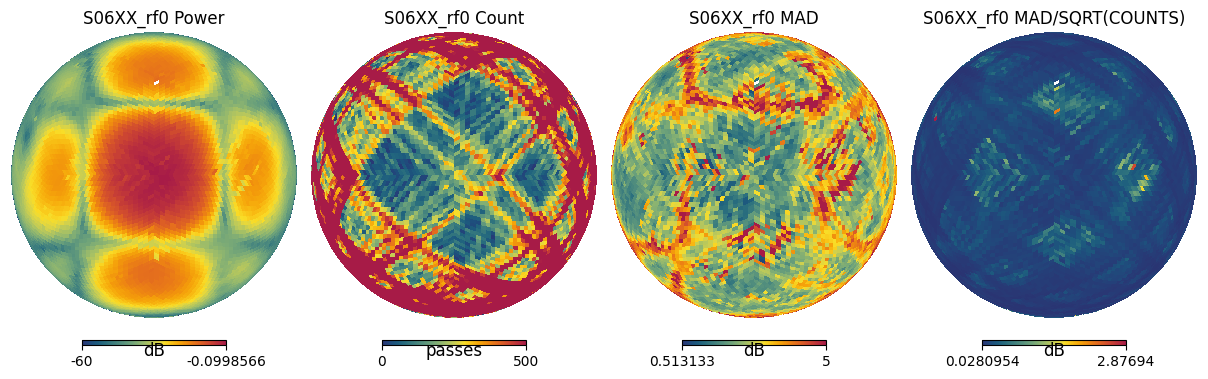

In [10]:
pf_mc_pval = PassFile("../passes/monotonic_concave_5hz_pval/S06XX_rf0XX_passes.h5")

passes_mc_pval = pf_mc_pval.read_passes(pointing=0)

pow_hpx_mc_pval, count_hpx_mc_pval, mad_hpx_mc_pval = passes_to_healpix(passes_mc_pval, nside=32)
scaled_mad = mad_hpx_mc_pval / np.sqrt(count_hpx_mc_pval)

fig = plt.figure(figsize=(12, 4))

hp.orthview(pow_hpx_mc_pval, fig=fig, sub=(1, 4, 1), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Power", unit="dB", cmap=prd, min=-60)
hp.orthview(count_hpx_mc_pval, fig=fig, sub=(1, 4, 2), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Count", unit="passes", cmap=prd, max=500)
hp.orthview(mad_hpx_mc_pval, fig=fig, sub=(1, 4, 3), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 MAD", unit="dB", cmap=prd, max=5)
hp.orthview(scaled_mad, fig=fig, sub=(1, 4, 4), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 MAD/SQRT(COUNTS)", unit="dB", cmap=prd)

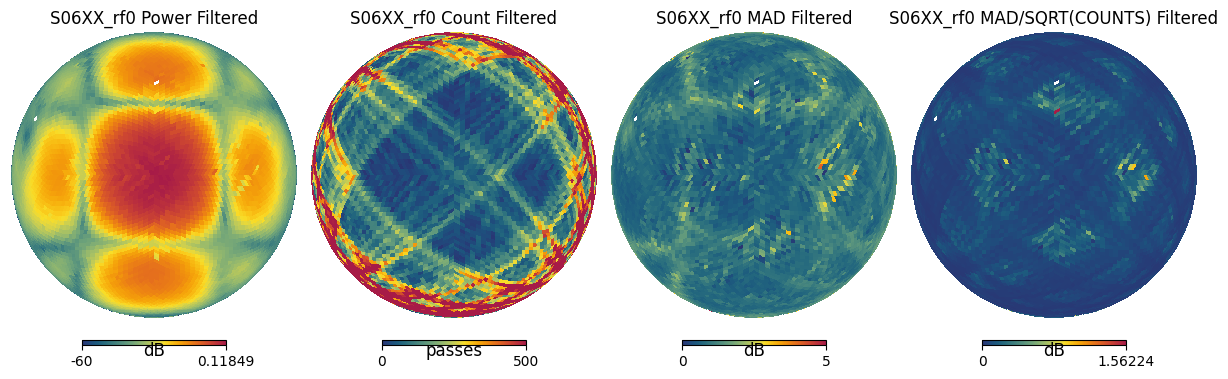

In [86]:
pf_mc_pval = PassFile("../passes/monotonic_concave_5hz_pval/S06XX_rf0XX_passes.h5")
passes_mc_pval = pf_mc_pval.read_passes(pointing=0)


filtered_power_map, count_map, mad_map, scaled_mad_map = passes_to_healpix_filtered(
    passes_mc_pval,
    nside=32,
    min_alt_deg=0.0,
    outlier_threshold=0.5
)

fig = plt.figure(figsize=(12, 4))

hp.orthview(filtered_power_map, fig=fig, sub=(1, 4, 1), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Power Filtered", unit="dB", cmap=prd, min=-60)
hp.orthview(count_map, fig=fig, sub=(1, 4, 2), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Count Filtered", unit="passes", cmap=prd, max=500)
hp.orthview(mad_map, fig=fig, sub=(1, 4, 3), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 MAD Filtered", unit="dB", cmap=prd, max=5)
hp.orthview(scaled_mad_map, fig=fig, sub=(1, 4, 4), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 MAD/SQRT(COUNTS) Filtered", unit="dB", cmap=prd)

91


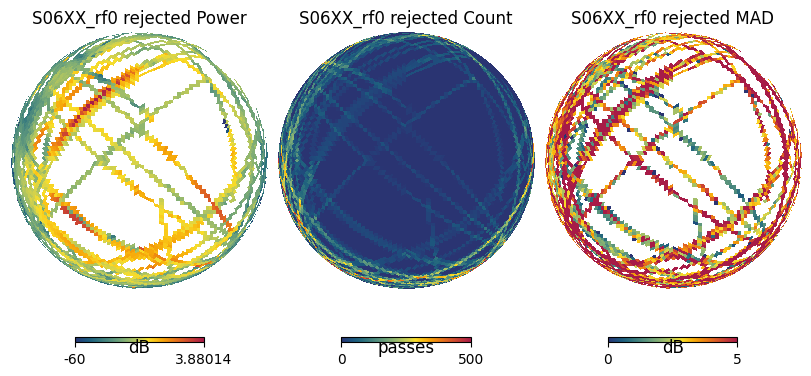

In [68]:
pf_mc_pval = PassFile("../passes/monotonic_concave_5hz_pval/S06XX_rf0XX_passes_rejected.h5")

passes_mc_pval = pf_mc_pval.read_passes(pointing=0)
print(len(passes_mc_pval))

pow_hpx_mc_pval, count_hpx_mc_pval, mad_hpx_mc_pval = passes_to_healpix(passes_mc_pval, nside=32)

fig = plt.figure(figsize=(8, 9.6))

hp.orthview(pow_hpx_mc_pval, fig=fig, sub=(1, 3, 1), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 rejected Power", unit="dB", cmap=prd, min=-60)
hp.orthview(count_hpx_mc_pval, fig=fig, sub=(1, 3, 2), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 rejected Count", unit="passes", cmap=prd, max=500)
hp.orthview(mad_hpx_mc_pval, fig=fig, sub=(1, 3, 3), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 rejected MAD", unit="dB", cmap=prd, max=5)

In [48]:
np.nanargmax(pow_hpx_mc_pval)

np.int64(28)

In [51]:
10**(0.1*pow_hpx_mc_pval[28])

np.float64(0.9772694889748529)

In [59]:
np.rad2deg(hp.pix2ang(32, np.arange(100)))[0]

array([ 1.46197116,  1.46197116,  1.46197116,  1.46197116,  2.92418036,
        2.92418036,  2.92418036,  2.92418036,  2.92418036,  2.92418036,
        2.92418036,  2.92418036,  4.38686596,  4.38686596,  4.38686596,
        4.38686596,  4.38686596,  4.38686596,  4.38686596,  4.38686596,
        4.38686596,  4.38686596,  4.38686596,  4.38686596,  5.85026706,
        5.85026706,  5.85026706,  5.85026706,  5.85026706,  5.85026706,
        5.85026706,  5.85026706,  5.85026706,  5.85026706,  5.85026706,
        5.85026706,  5.85026706,  5.85026706,  5.85026706,  5.85026706,
        7.31462379,  7.31462379,  7.31462379,  7.31462379,  7.31462379,
        7.31462379,  7.31462379,  7.31462379,  7.31462379,  7.31462379,
        7.31462379,  7.31462379,  7.31462379,  7.31462379,  7.31462379,
        7.31462379,  7.31462379,  7.31462379,  7.31462379,  7.31462379,
        8.78017768,  8.78017768,  8.78017768,  8.78017768,  8.78017768,
        8.78017768,  8.78017768,  8.78017768,  8.78017768,  8.78

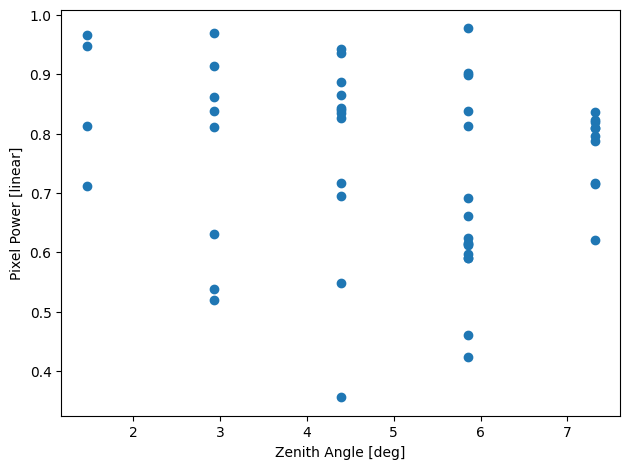

In [62]:
fig, ax = plt.subplots()

ax.scatter(np.rad2deg(hp.pix2ang(32, np.arange(50)))[0], 10**(0.1*pow_hpx_mc_pval[:50]))

ax.set_xlabel("Zenith Angle [deg]")
ax.set_ylabel("Pixel Power [linear]")

plt.tight_layout()
plt.show()

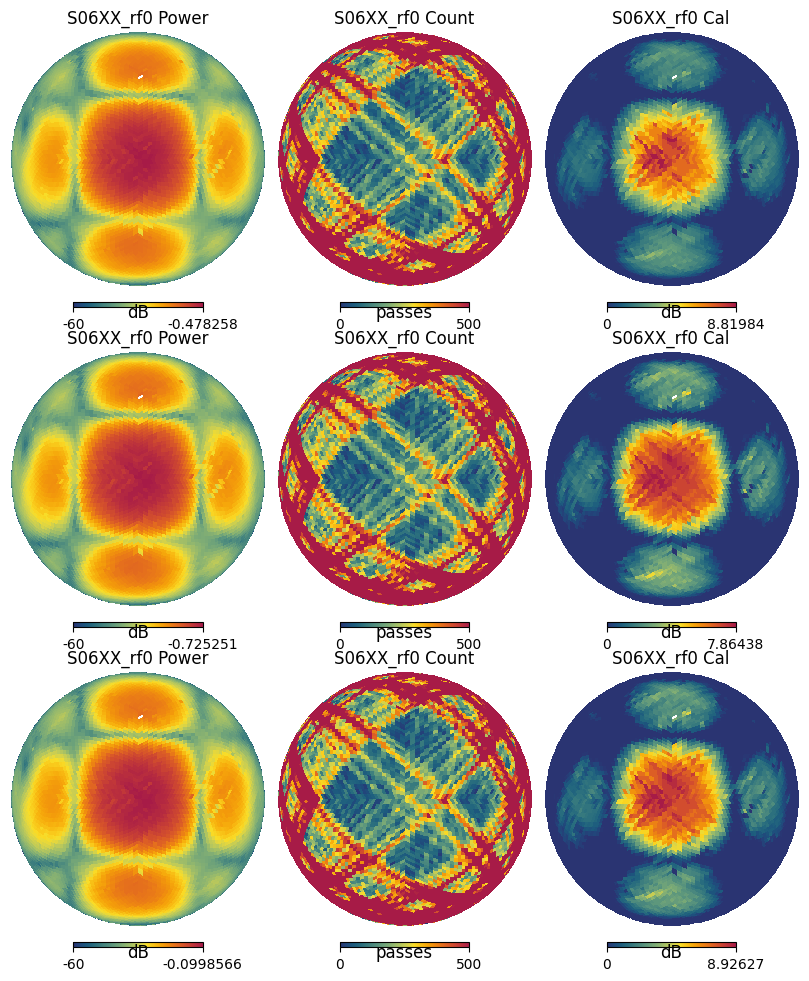

In [11]:
pf_mc_corr = PassFile("../passes/monotonic_concave_5hz_corr/S06XX_rf0XX_passes.h5")
pf_mc_corr_median = PassFile("../passes/monotonic_concave_5hz_corr_median/S06XX_rf0XX_passes.h5")
pf_mc_pval = PassFile("../passes/monotonic_concave_5hz_pval/S06XX_rf0XX_passes.h5")

passes_mc_corr = pf_mc_corr.read_passes(pointing=0)
passes_mc_corr_median = pf_mc_corr_median.read_passes(pointing=0)
passes_mc_pval = pf_mc_pval.read_passes(pointing=0)

pow_hpx_mc_corr, cal_hpx_mc_corr, count_hpx_mc_corr = passes_to_healpix_concave_monotonic(passes_mc_corr, nside=32)
pow_hpx_mc_corr_median, cal_hpx_mc_corr_median, count_hpx_mc_corr_median = passes_to_healpix_concave_monotonic(passes_mc_corr_median, nside=32)
pow_hpx_mc_pval, cal_hpx_mc_pval, count_hpx_mc_pval = passes_to_healpix_concave_monotonic(passes_mc_pval, nside=32)

fig = plt.figure(figsize=(8, 9.6))

hp.orthview(pow_hpx_mc_corr, fig=fig, sub=(3, 3, 1), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Power", unit="dB", cmap=prd, min=-60)
hp.orthview(count_hpx_mc_corr, fig=fig, sub=(3, 3, 2), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Count", unit="passes", cmap=prd, max=500)
hp.orthview(cal_hpx_mc_corr, fig=fig, sub=(3, 3, 3), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Cal", unit="dB", cmap=prd)

hp.orthview(pow_hpx_mc_corr_median, fig=fig, sub=(3, 3, 4), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Power", unit="dB", cmap=prd, min=-60)
hp.orthview(count_hpx_mc_corr_median, fig=fig, sub=(3, 3, 5), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Count", unit="passes", cmap=prd, max=500)
hp.orthview(cal_hpx_mc_corr_median, fig=fig, sub=(3, 3, 6), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Cal", unit="dB", cmap=prd)

hp.orthview(pow_hpx_mc_pval, fig=fig, sub=(3, 3, 7), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Power", unit="dB", cmap=prd, min=-60)
hp.orthview(count_hpx_mc_pval, fig=fig, sub=(3, 3, 8), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Count", unit="passes", cmap=prd, max=500)
hp.orthview(cal_hpx_mc_pval, fig=fig, sub=(3, 3, 9), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Cal", unit="dB", cmap=prd)

In [305]:
def plot_monotonic_concave_diagnostics(
    tile_ref,
    path_mc, 
    path_orig,
    out_dir,
    nside=32, 
    za_max=90, 
    figsize=(10, 8)
):
    """Plot diagnostics between new monotonic concave and original RFE calibration"""
    pf_mc = PassFile(f"{path_mc}/{tile_ref}_passes.h5")
    passes_mc = pf_mc.read_passes(pointing=0)
    print(len(passes_mc))

    pf_orig = PassFile(f"{path_orig}/{tile_ref}_passes.h5")
    passes_orig = pf_orig.read_passes(pointing=0)

    pow_hpx_mc, cal_hpx_mc, count_hpx_mc = passes_to_healpix_concave_monotonic(passes_mc, nside=nside)
    pow_hpx_orig, count_hpx_orig = passes_to_healpix(passes_orig, nside=nside)

    if "XX" in tile_ref:
        pidx=0
    else:
        pidx=1
    
    beam = mwa_hyperbeam.FEEBeam(os.environ["MWA_BEAM_FILE"])
    mwa_map = hyperbeam_healpix(
        beam,
        nside=nside,
        freq_hz=137e6,
        amps=np.ones(16),
    )
    hyperbeam_map = np.full(hp.nside2npix(32), np.nan, dtype=float)
    hyperbeam_map[: mwa_map.shape[0]] = mwa_map[:, pidx]

    hyp = healpix_ew_ns_slices(hyperbeam_map, nside=nside, za_max=za_max)
    sat_mc = healpix_ew_ns_slices(pow_hpx_mc, nside=nside, za_max=za_max)
    sat_orig = healpix_ew_ns_slices(pow_hpx_orig, nside=nside, za_max=za_max)

    ew_za, ew_sat_orig = sat_orig["EW"]
    _, ew_sat_mc = sat_mc["EW"]
    _, ew_hyp = hyp["EW"]

    ns_za, ns_sat_orig = sat_orig["NS"]
    _, ns_sat_mc = sat_mc["NS"]
    _, ns_hyp = hyp["NS"]

    max_sat_mc = np.nanmax([np.nanmax(ew_sat_mc), np.nanmax(ns_sat_mc)])

    fig = plt.figure(figsize=figsize)
    
    hp.orthview(
        pow_hpx_mc,
        fig=fig,
        sub=(2, 3, 1),
        rot=(0, 90, 180),
        half_sky=True,
        title="",
        unit="Beam Power [dB]",
        fontsize={'cbar_label': 10},
        format="%.2f",
        cmap=prd,
        min=-60,
        max=max_sat_mc,
    )
    
    hp.orthview(
        cal_hpx_mc,
        fig=fig,
        sub=(2, 3, 4),
        rot=(0, 90, 180),
        half_sky=True,
        title="",
        unit="Cal Power [dB]",
        fontsize={'cbar_label': 10},
        format="%.2f",
        cmap=prd,
    )
    
    # Create shared axes for the four slice panels.
    ax2 = fig.add_subplot(2, 3, 2)
    ax3 = fig.add_subplot(2, 3, 3, sharey=ax2)
    ax5 = fig.add_subplot(2, 3, 5, sharex=ax2)
    ax6 = fig.add_subplot(2, 3, 6, sharex=ax3, sharey=ax5)
    
    # EW slice in dB.
    ax2.plot(ew_za, ew_hyp, lw=1, ls=":", color="k", label="FEE")
    ax2.plot(ew_za, ew_sat_orig, lw=2, color=prd(0.9), label="SAT ORIG")
    ax2.plot(ew_za, ew_sat_mc, lw=2, color=prd(0.4), label="SAT MONO CONC")
    ax2.set_title("EW Slice")
    ax2.set_ylabel("Beam [dB]")
    ax2.legend(loc="lower center")
    
    # NS slice in dB.
    ax3.plot(ns_za, ns_hyp, lw=1, ls=":", color="k", label="FEE")
    ax3.plot(ns_za, ns_sat_orig, lw=2, color=prd(0.9), label="SAT ORIG")
    ax3.plot(ns_za, ns_sat_mc, lw=2, color=prd(0.4), label="SAT MONO CONC")
    ax3.set_title("NS Slice")
    ax3.legend(loc="lower center")
    
    # EW slice in linear units.
    ax5.plot(ew_za, 10 ** (0.1 * ew_hyp), lw=1, ls=":", color="k", label="FEE")
    ax5.plot(ew_za, 10 ** (0.1 * ew_sat_orig), lw=2, color=prd(0.9), label="SAT ORIG")
    ax5.plot(ew_za, 10 ** (0.1 * ew_sat_mc), lw=2, color=prd(0.4), label="SAT MONO CONC")
    ax5.set_xlabel("Zenith angle [deg]")
    ax5.set_ylabel("Beam [linear]")
    
    # NS slice in linear units.
    ax6.plot(ns_za, 10 ** (0.1 * ns_hyp), lw=1, ls=":", color="k", label="FEE")
    ax6.plot(ns_za, 10 ** (0.1 * ns_sat_orig), lw=2, color=prd(0.9), label="SAT ORIG")
    ax6.plot(ns_za, 10 ** (0.1 * ns_sat_mc), lw=2, color=prd(0.4), label="SAT MONO CONC")
    ax6.set_xlabel("Zenith angle [deg]")
    
    # Hide repeated tick labels.
    ax2.tick_params(labelbottom=False)
    ax3.tick_params(labelbottom=False, labelleft=False)
    ax6.tick_params(labelleft=False)
    
    # Reduce whitespace between the four right-hand panels.
    fig.subplots_adjust(
        left=0.02,
        right=0.98,
        bottom=0.08,
        top=0.9,
        wspace=0.22,
        hspace=0.12,
    )

    fig.suptitle(f"{tile_ref} Monotonic Concave RFE Calibration Fit", y=0.98, x=0.62)

    # Path(out_dir).mkdir(parents=True, exist_ok=True)
    # plt.savefig(f"{out_dir}/{tile_ref}_Monotonic_Concave_RFE_CalibrationFit.pdf")
    plt.show()

S06XX_rf0XX
1759


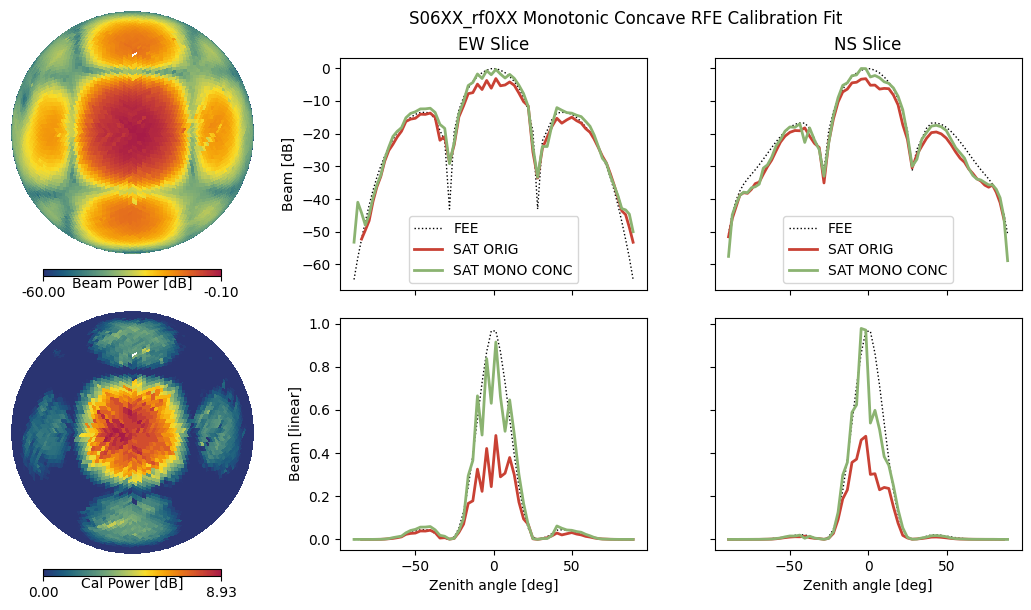

S07XX_rf0XX
1893


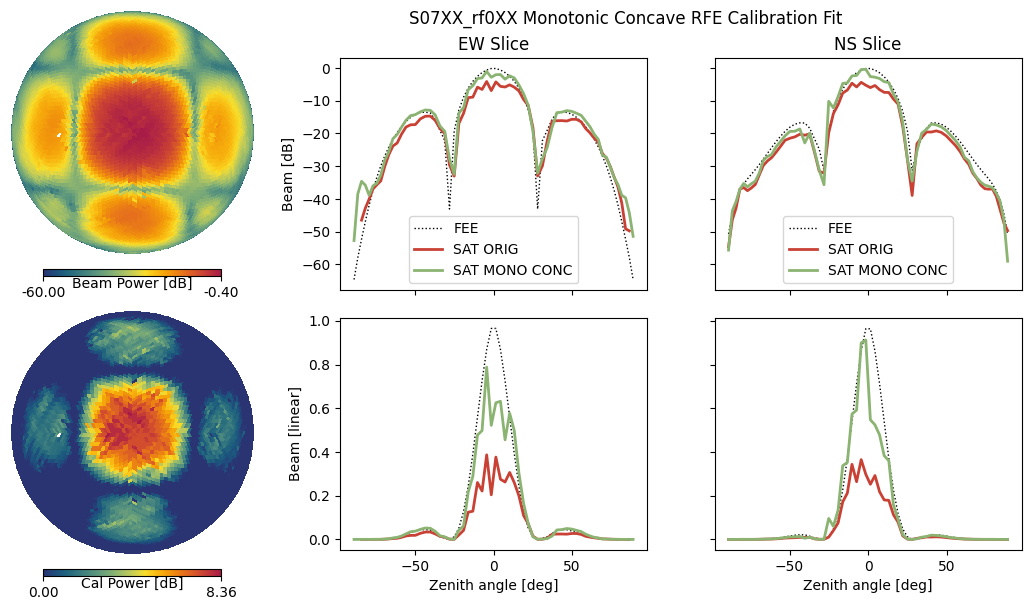

S08XX_rf0XX
1865


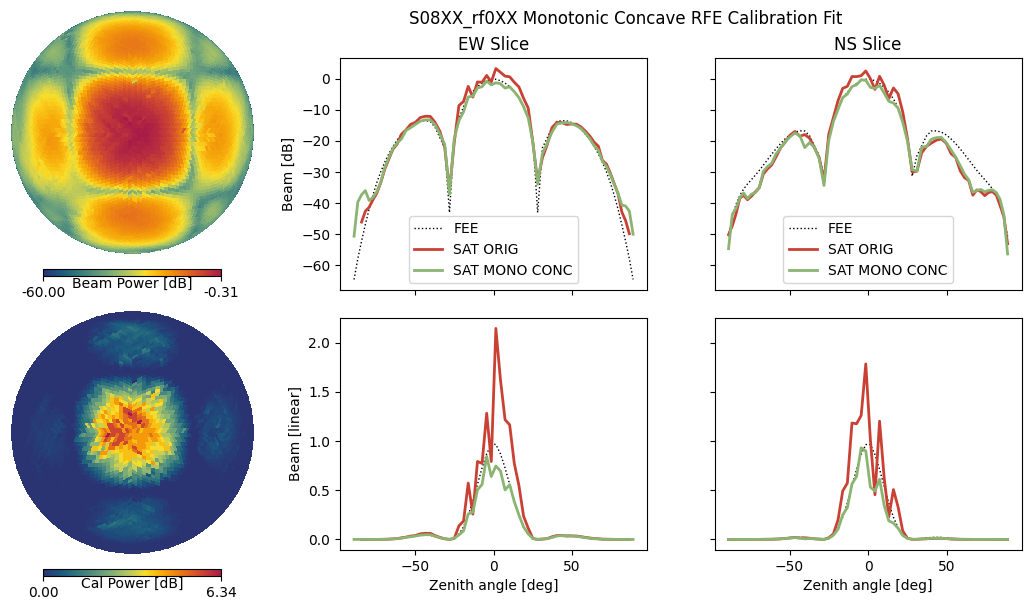

S09XX_rf0XX
1689


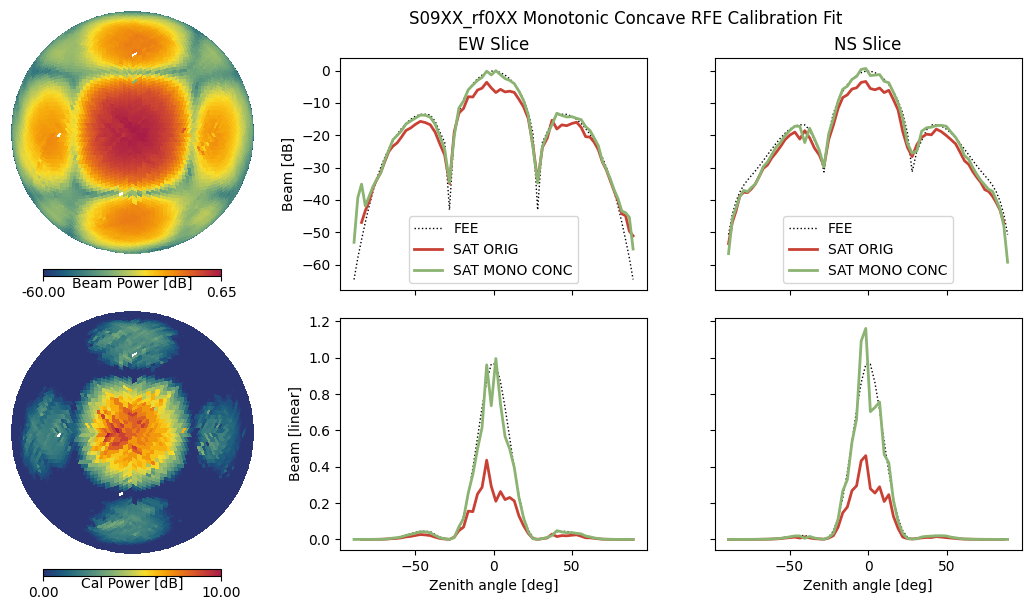

S10XX_rf0XX
1345


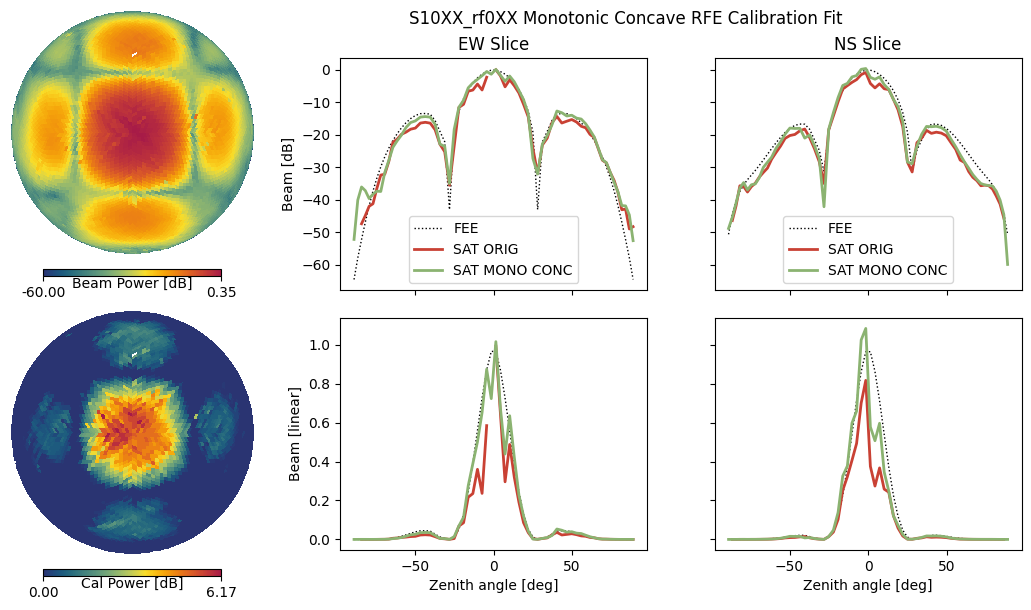

S12XX_rf0XX
1396


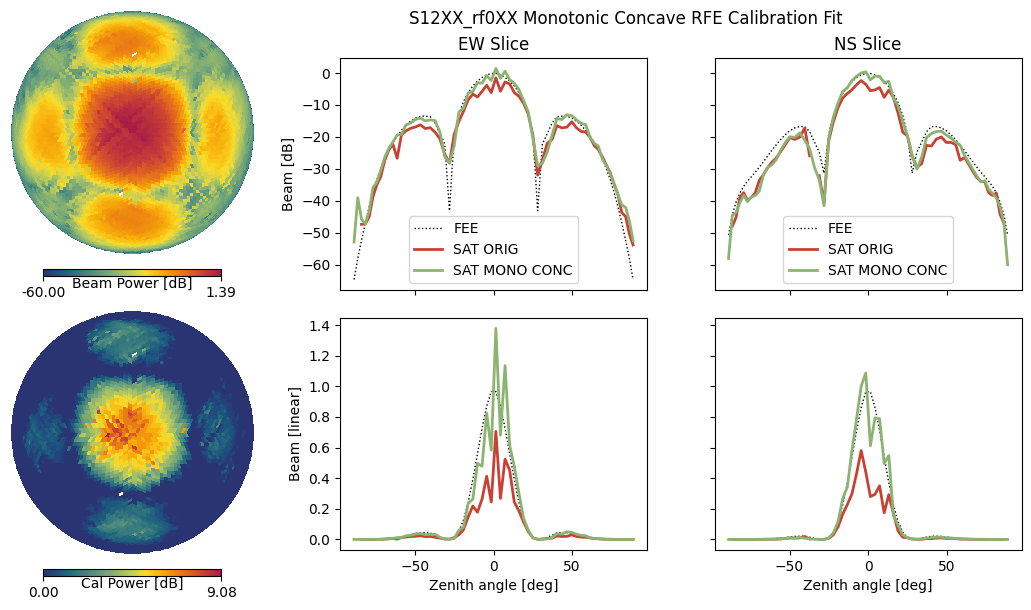

S29XX_rf0XX
1141


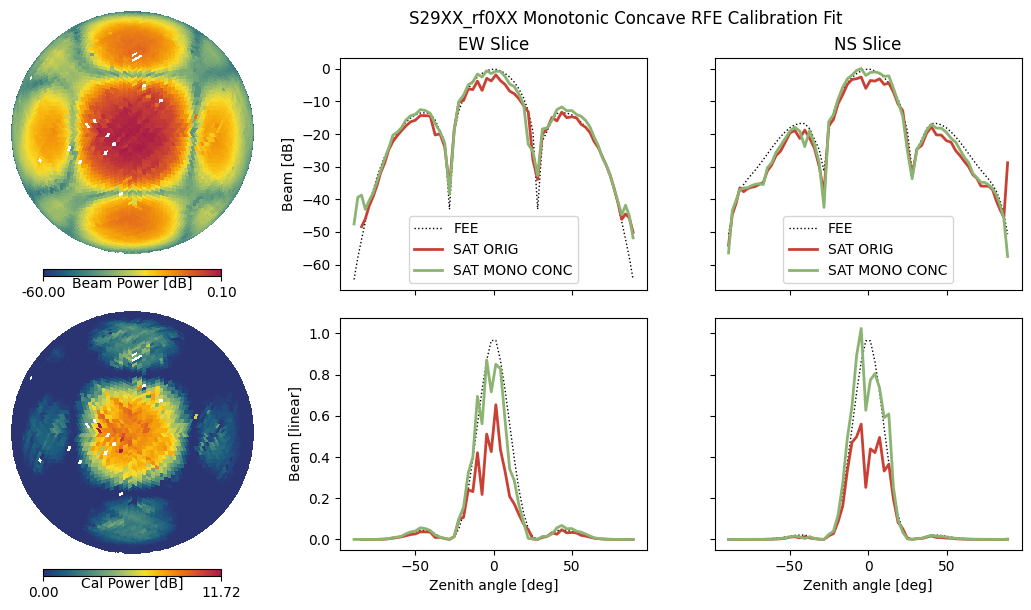

S30XX_rf0XX
1676


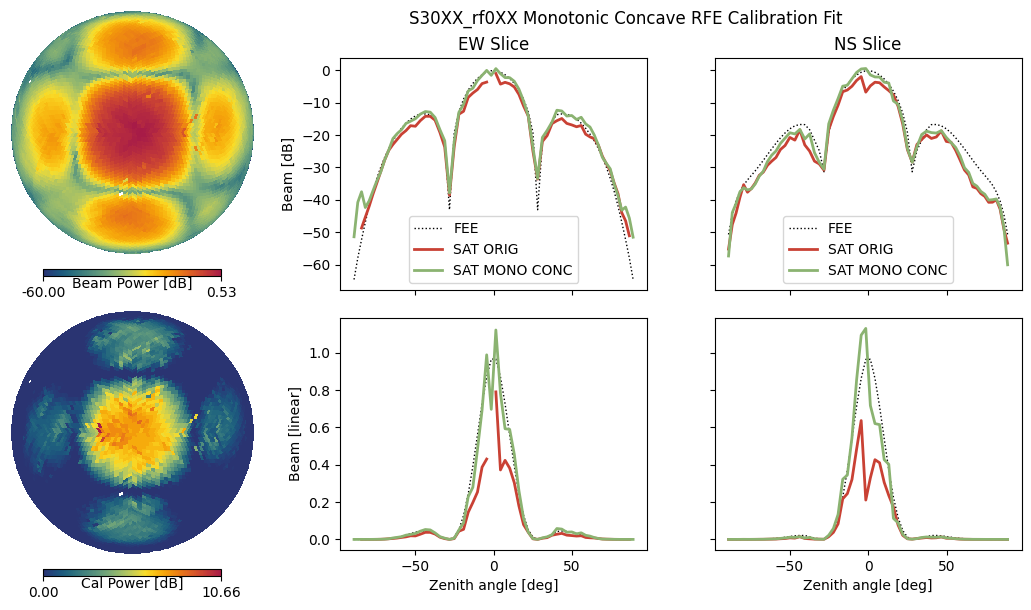

S31XX_rf0XX
1467


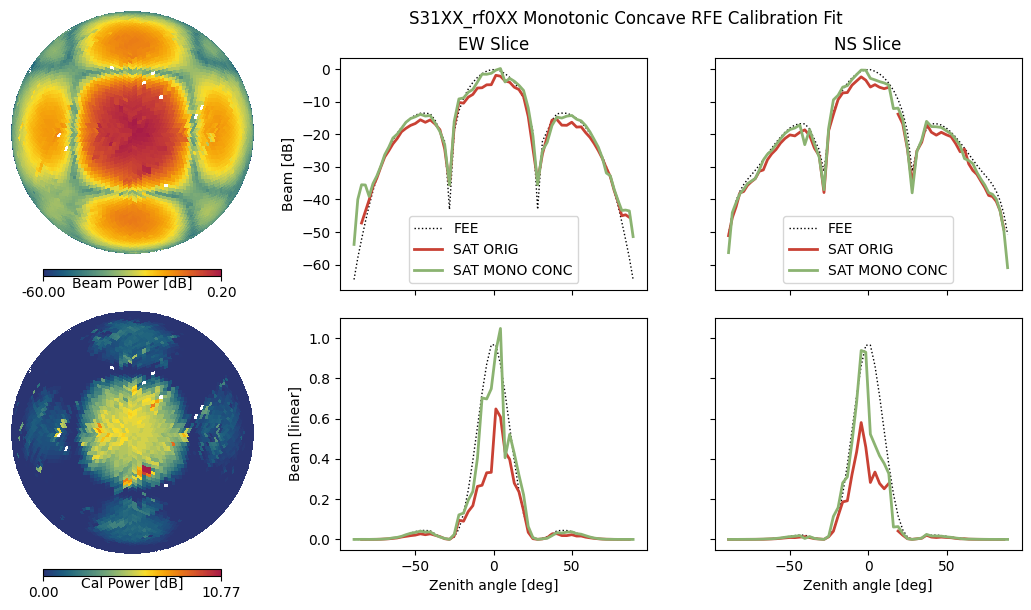

S32XX_rf0XX
1918


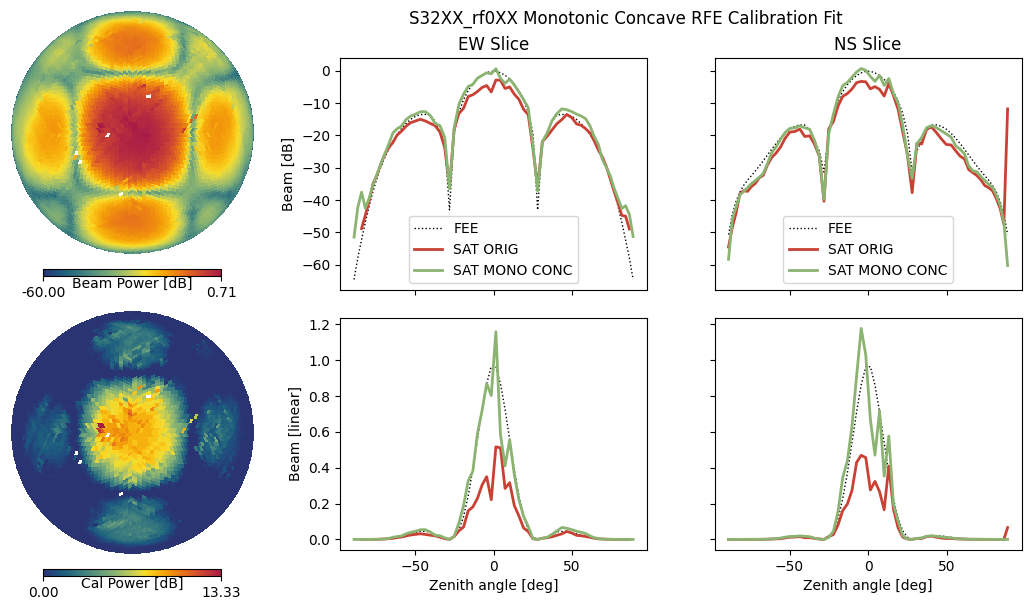

S33XX_rf0XX
1628


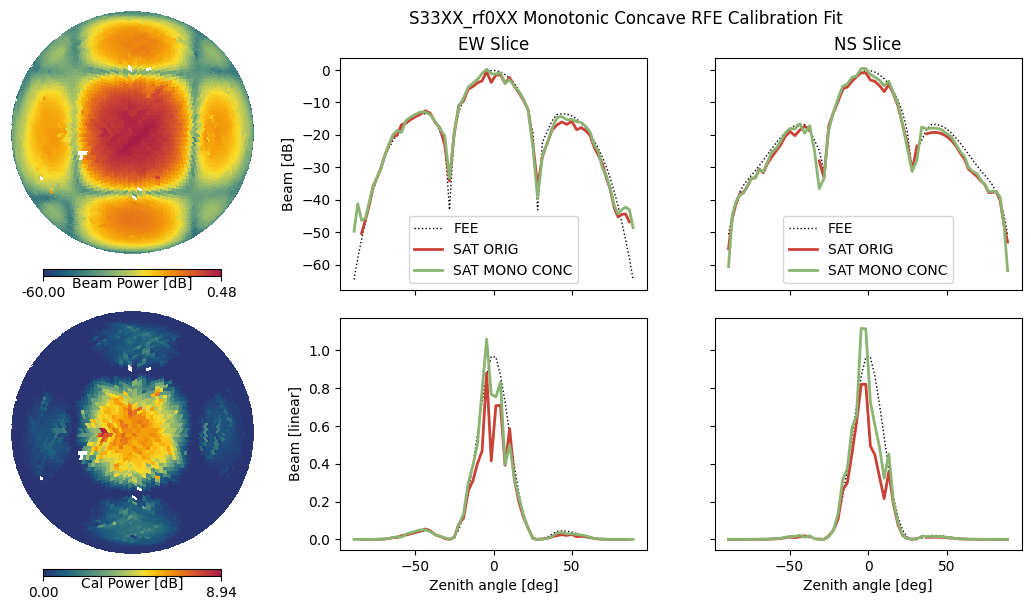

S34XX_rf0XX
1991


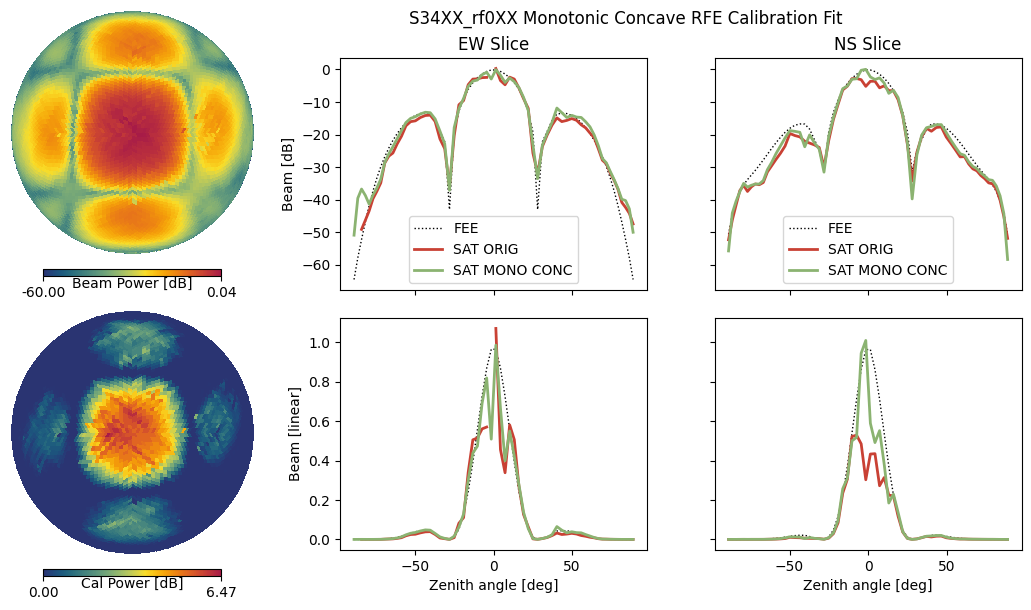

S35XX_rf0XX
1782


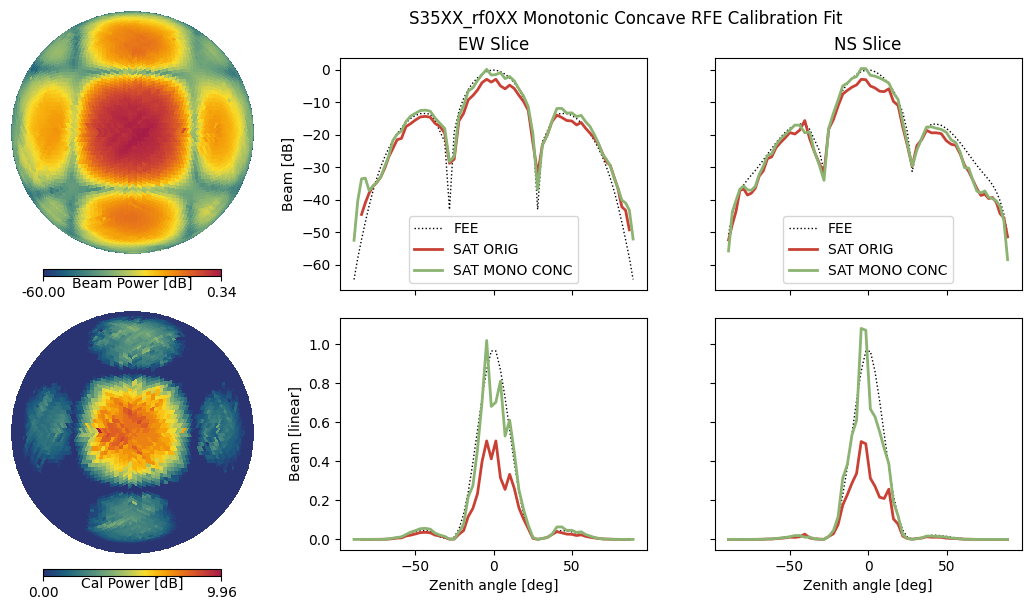

S36XX_rf0XX
2078


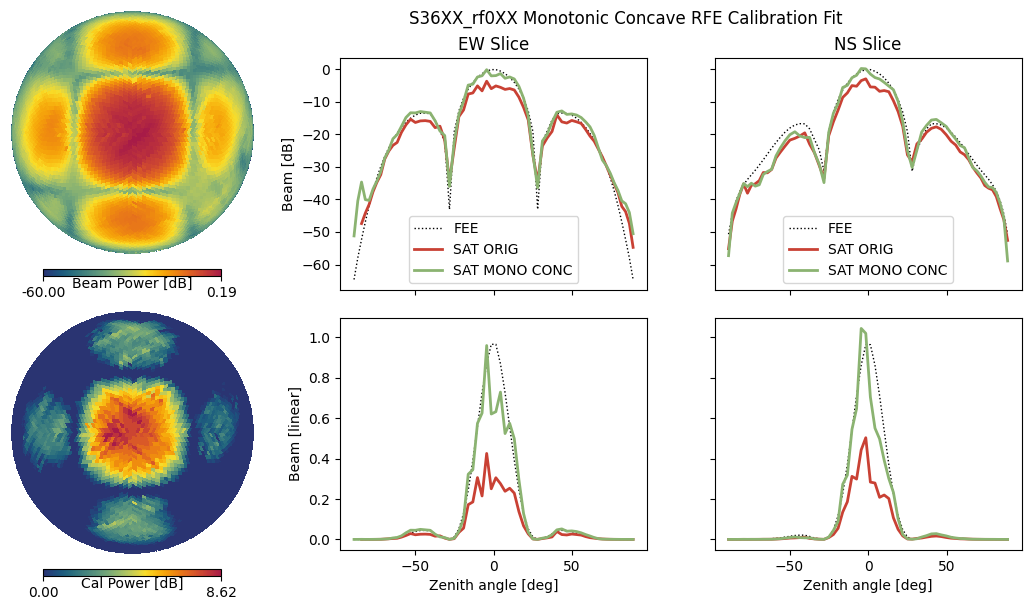

S06YY_rf0YY
1276


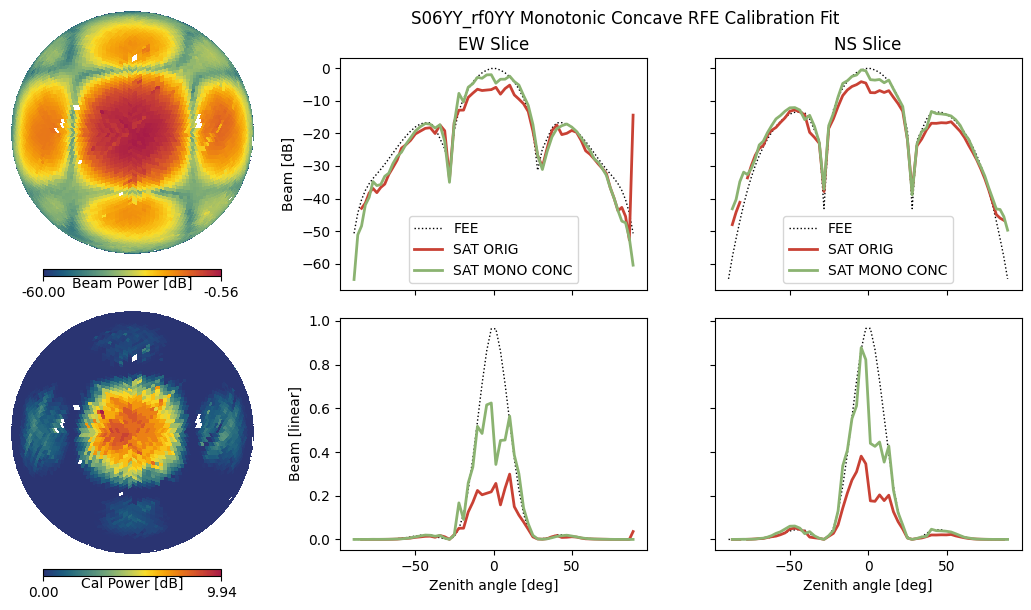

S07YY_rf0YY
1537


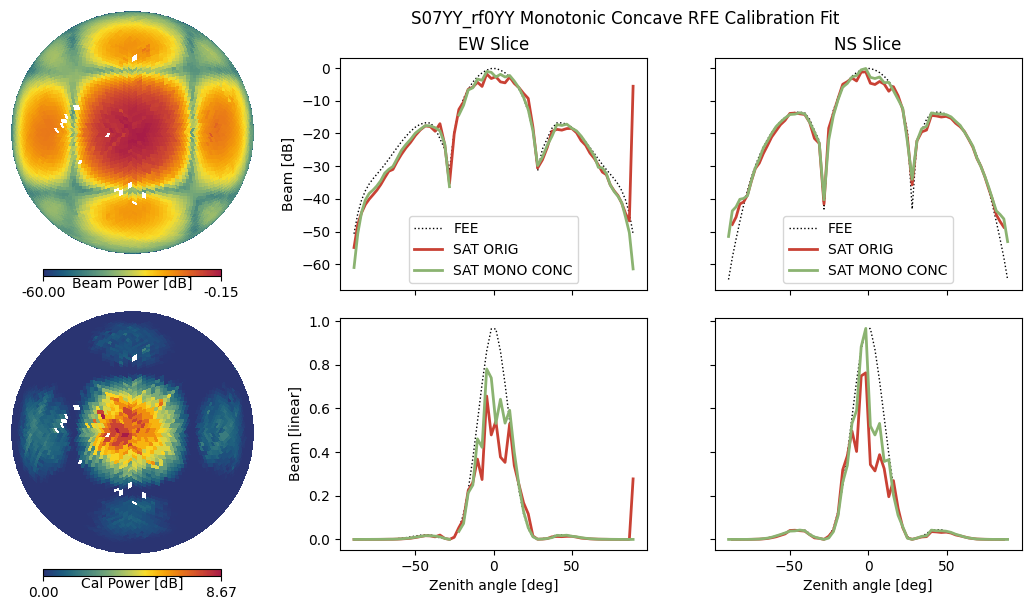

S08YY_rf0YY
1671


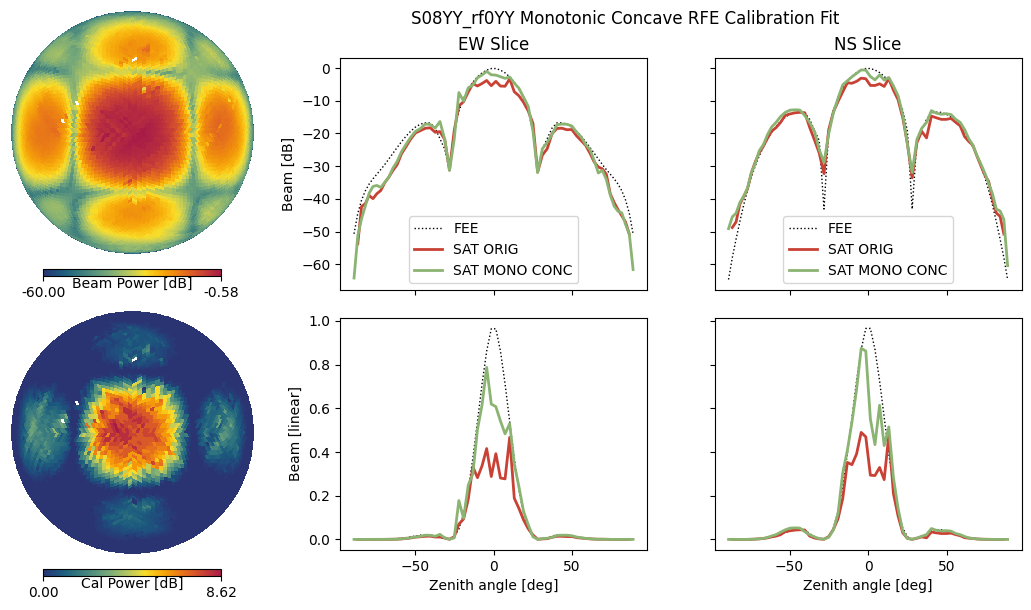

S09YY_rf0YY
1594


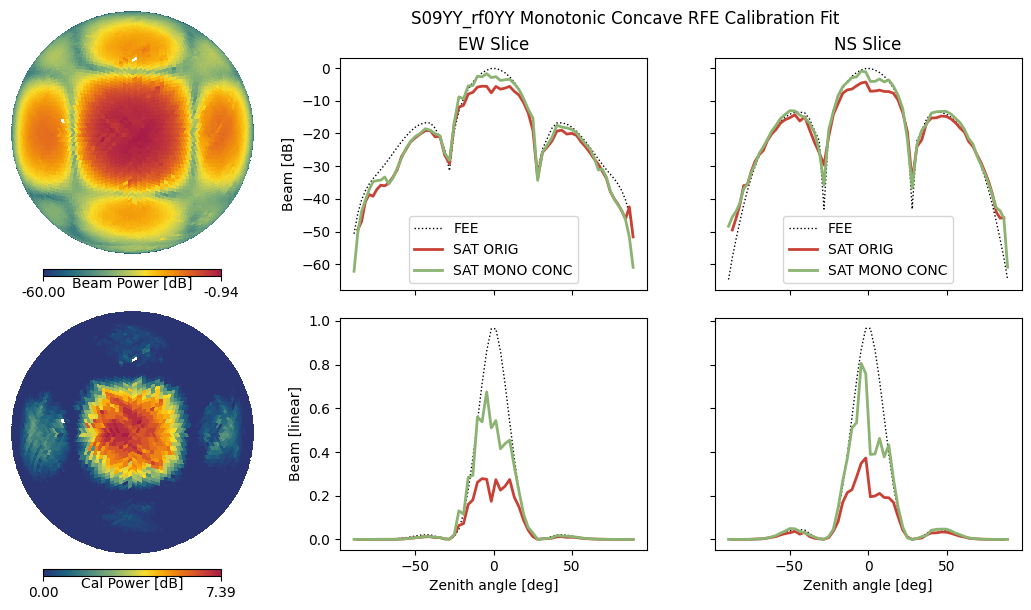

S10YY_rf0YY
1380


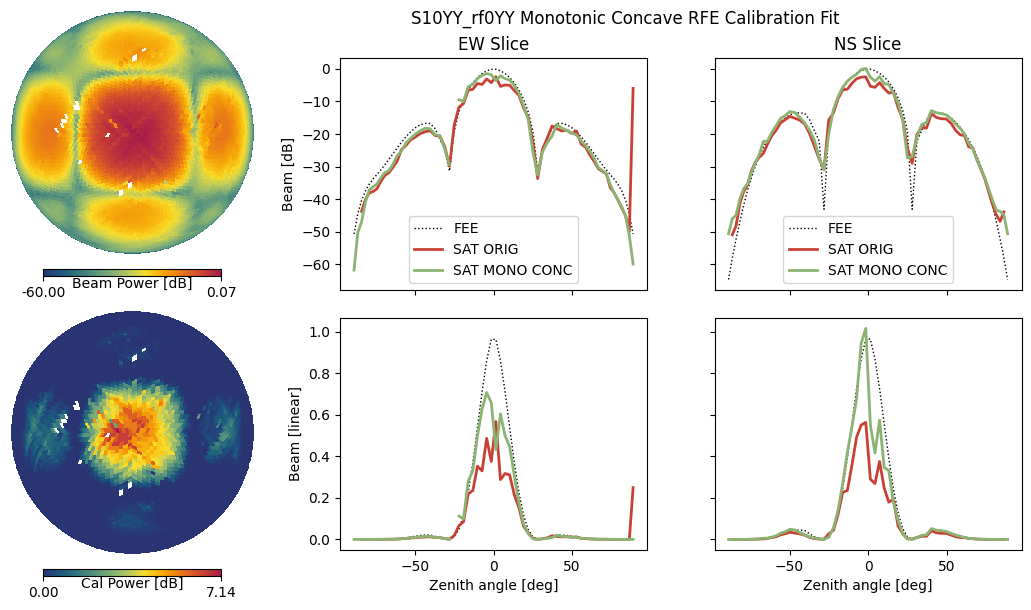

S12YY_rf0YY
1139


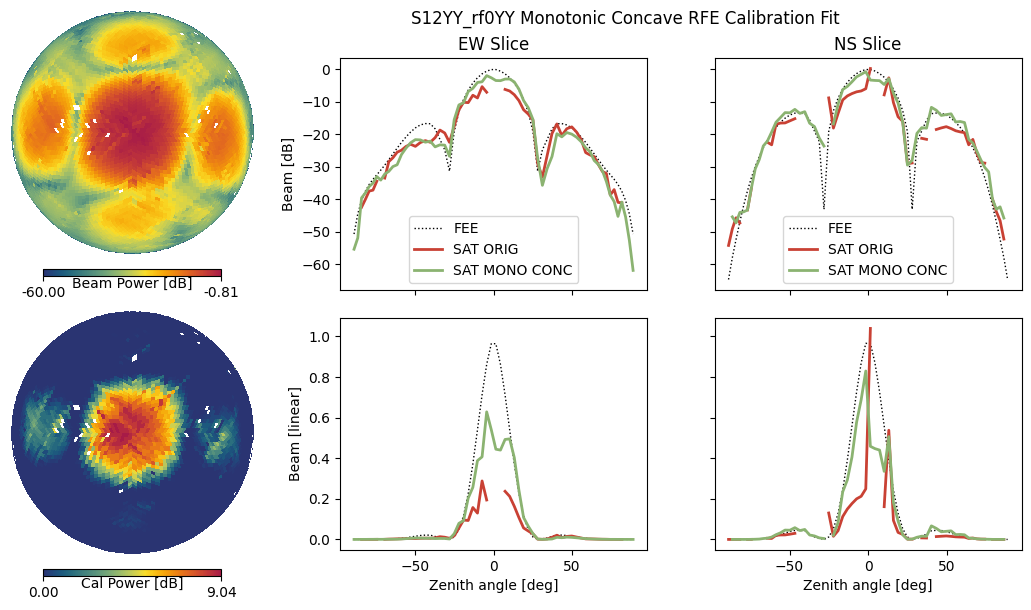

S29YY_rf0YY
913


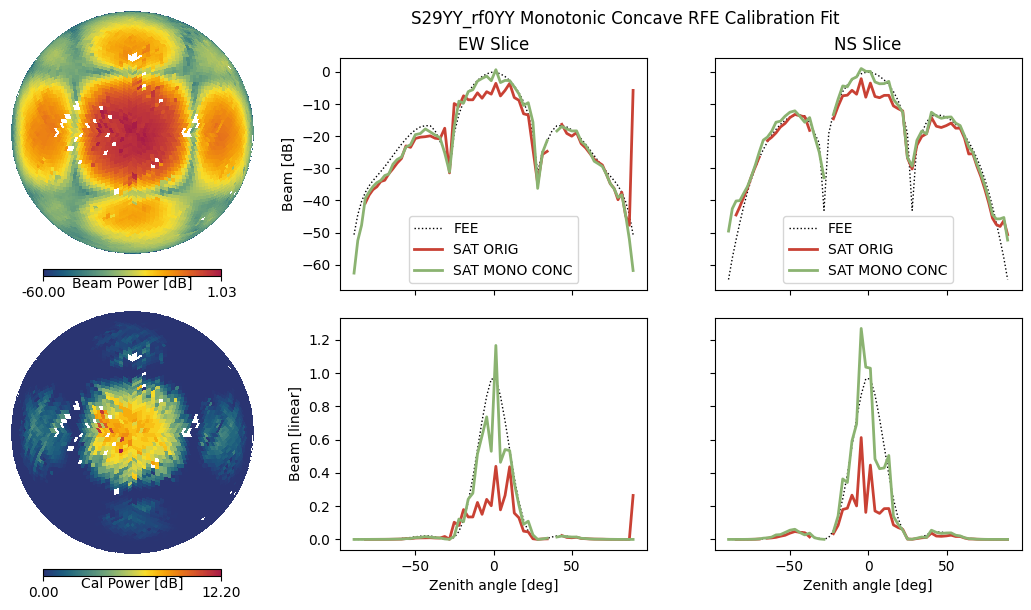

S30YY_rf0YY
1556


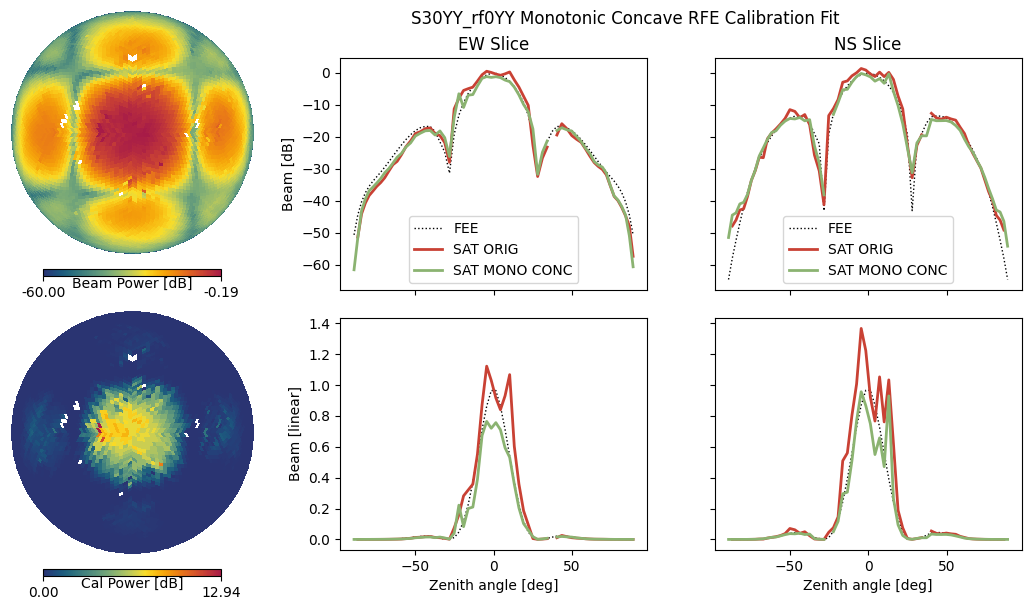

S31YY_rf0YY
1321


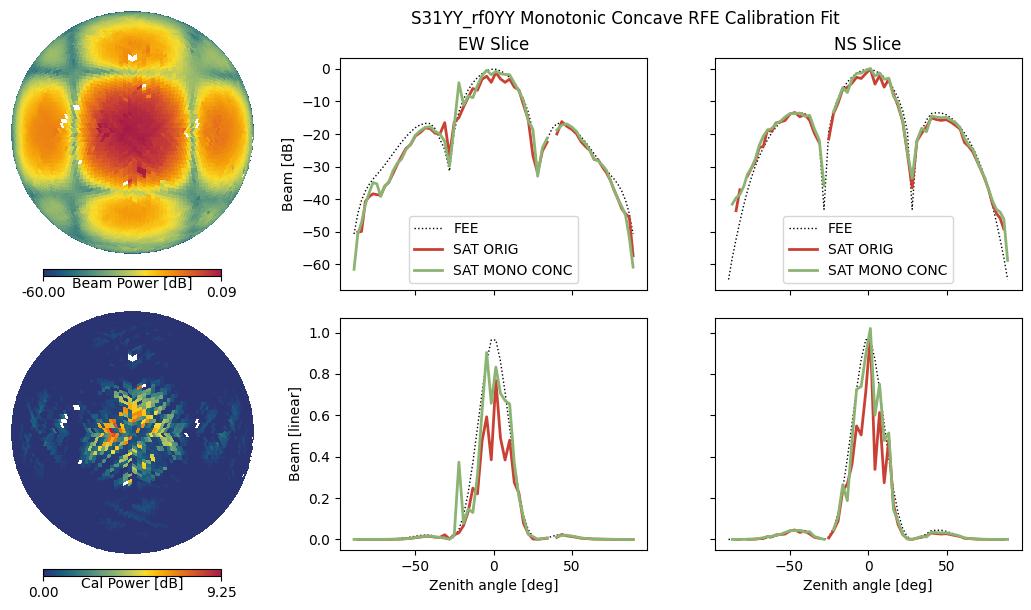

S32YY_rf0YY
1050


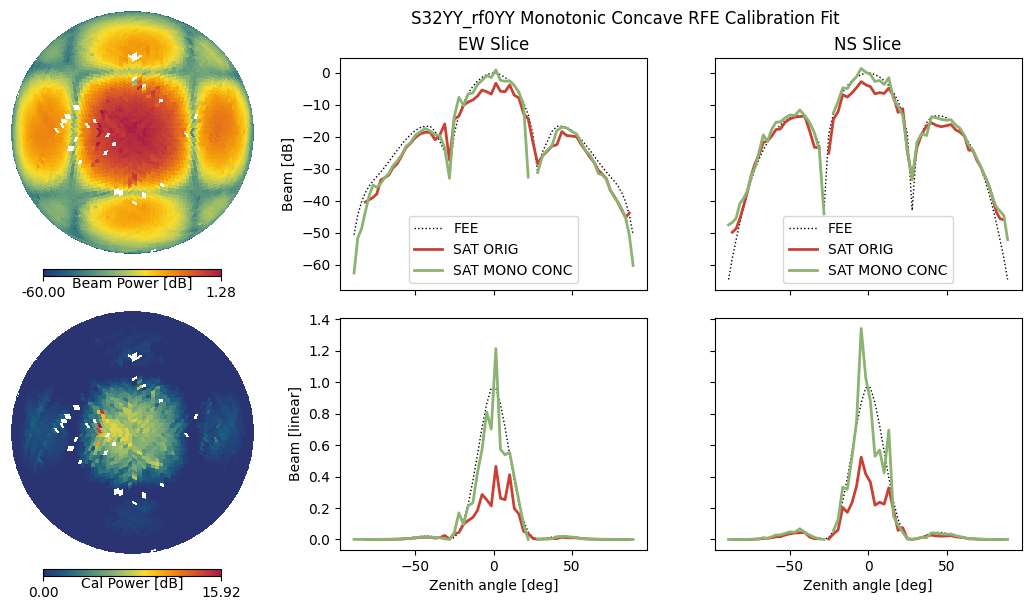

S33YY_rf0YY
1631


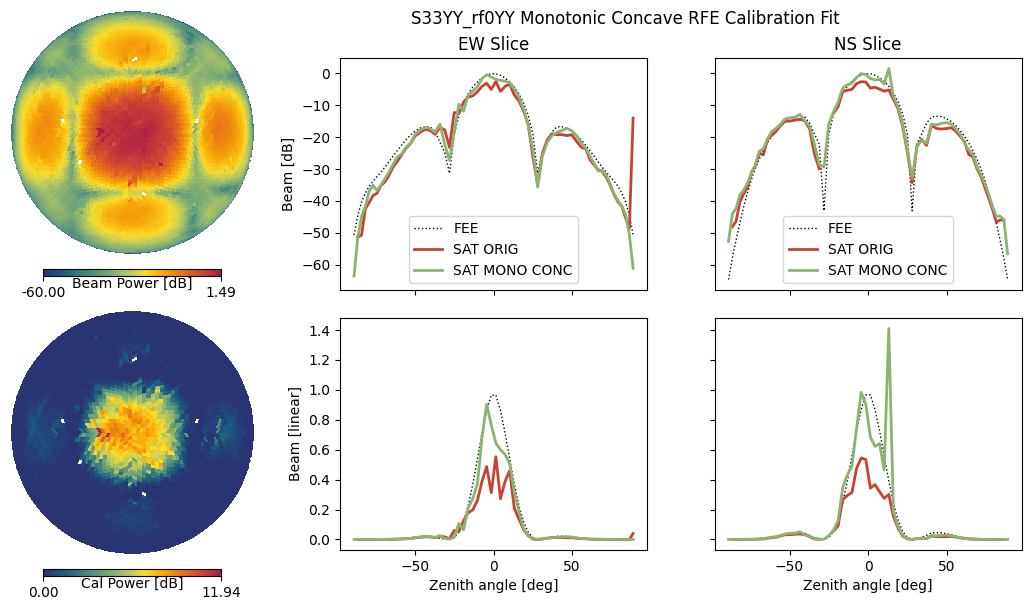

S34YY_rf0YY
1551


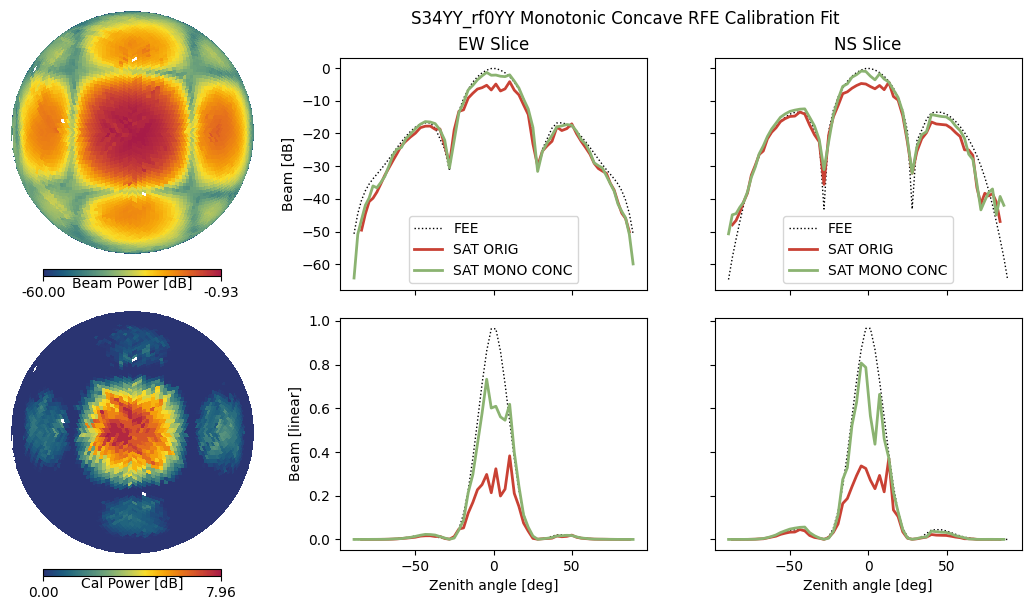

S35YY_rf0YY
1563


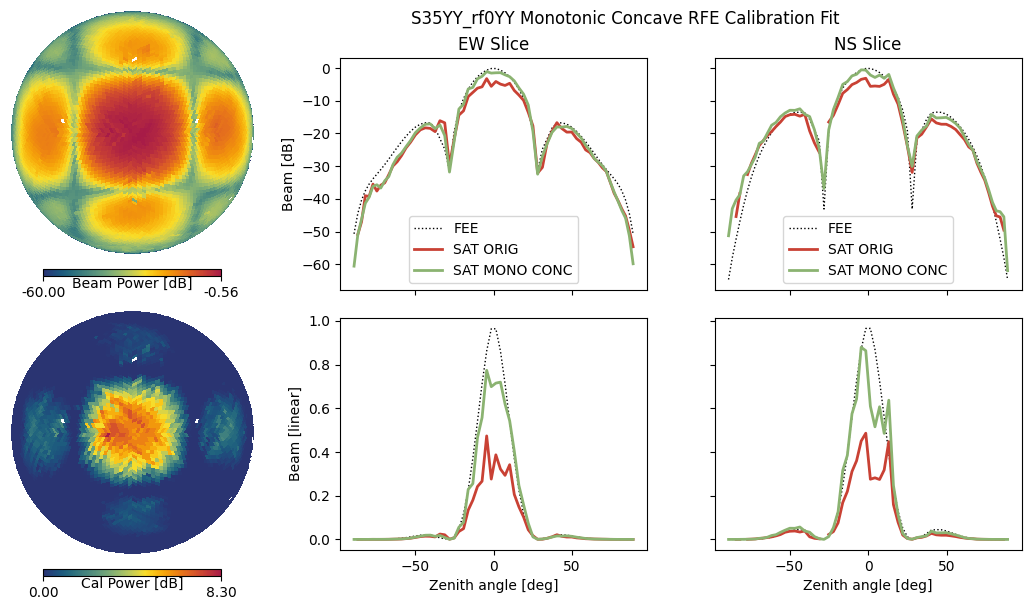

S36YY_rf0YY
1560


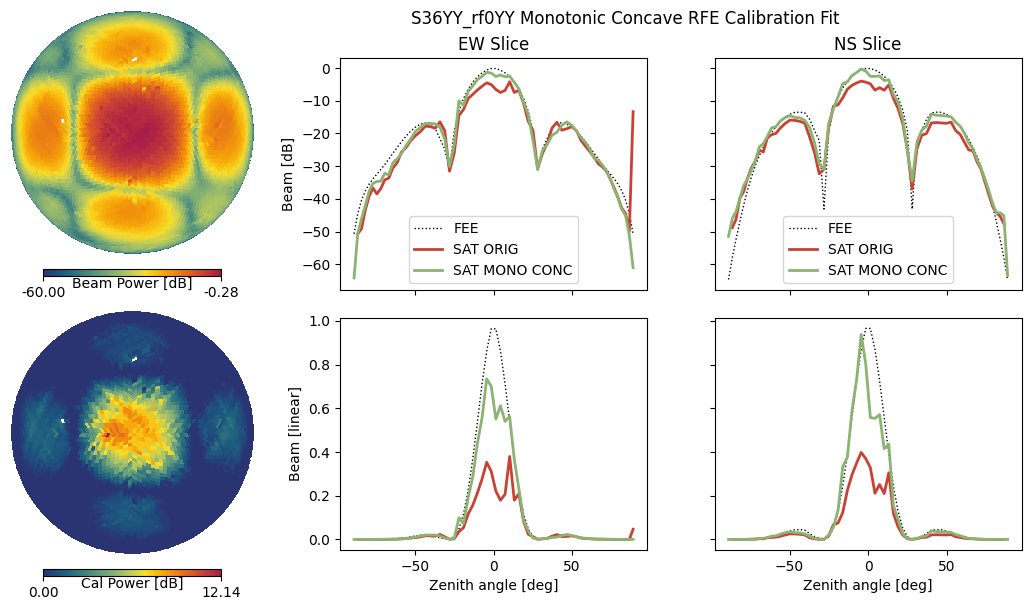

In [306]:
tiles = [
    "S06XX",
    "S06YY",
    "S07XX",
    "S07YY",
    "S08XX",
    "S08YY",
    "S09XX",
    "S09YY",
    "S10XX",
    "S10YY",
    "S12XX",
    "S12YY",
    "S29XX",
    "S29YY",
    "S30XX",
    "S30YY",
    "S31XX",
    "S31YY",
    "S32XX",
    "S32YY",
    "S33XX",
    "S33YY",
    "S34XX",
    "S34YY",
    "S35XX",
    "S35YY",
    "S36XX",
    "S36YY",
]

refs = [
    "rf0XX",
    "rf0YY",
    # "rf1XX",
    # "rf1YY",
]

for ref in refs:
    for tile in tiles:
        if ref[3:] in tile:
            print(f"{tile}_{ref}")

            plot_monotonic_concave_diagnostics(
                tile_ref=f"{tile}_{ref}",
                path_mc=f"../passes/monotonic_concave_5hz_pval/",
                path_orig=f"../passes/{ref[:3]}",
                out_dir="../data/plots/monotonic_concave_rfe_cali_5hz",
                nside=32, 
                za_max=90,
                figsize=(11, 6))

### Flagging Passes 5Hz

In [36]:
import numpy as np
from numpy.typing import NDArray
from scipy.optimize import least_squares

def evaluate_pass_fit(
    data_db,
    model_db,
    *,
    fit_min_db=-50.0,
    fit_max_db=0.0,
    min_samples=50,
):
    """Evaluate agreement between a measured pass and a fixed beam model."""
    data_db = np.asarray(data_db, dtype=float)
    model_db = np.asarray(model_db, dtype=float)

    if data_db.shape != model_db.shape:
        raise ValueError("data_db and model_db must have matching shapes.")

    mask = (
        np.isfinite(data_db)
        & np.isfinite(model_db)
        & (model_db >= fit_min_db)
        & (model_db <= fit_max_db)
    )

    if np.count_nonzero(mask) < min_samples:
        return None

    data_fit = data_db[mask]
    model_fit = model_db[mask]

    # Fit only an additive gain offset. The model shape is unchanged.
    offset_db = np.median(data_fit - model_fit)
    offset_model_db = model_db + offset_db

    residual_db = data_db - offset_model_db
    residual_fit = residual_db[mask]

    residual_median_db = np.median(residual_fit)
    residual_mad_db = 1.4826 * np.median(
        np.abs(residual_fit - residual_median_db)
    )
    residual_rms_db = np.sqrt(np.mean(residual_fit**2))

    if np.std(data_fit) > 0 and np.std(model_fit) > 0:
        correlation = np.corrcoef(data_fit, model_fit)[0, 1]
    else:
        correlation = np.nan

    return {
        "offset_db": float(offset_db),
        "residual_median_db": float(residual_median_db),
        "residual_mad_db": float(residual_mad_db),
        "residual_rms_db": float(residual_rms_db),
        "correlation": float(correlation),
        "model_dynamic_range_db": float(np.ptp(model_fit)),
        "residual_dynamic_range_db": float(np.ptp(residual_db[mask])),
        "n_samples": int(np.count_nonzero(mask)),
        "mask": mask,
        "offset_model_db": offset_model_db,
        "residual_db": residual_db,
    }

In [260]:
def passes_to_healpix(
    passes,
    offsets,
    nside: int = 32,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Bin satellite-pass power samples onto a HEALPix map.

    Samples from all passes are assigned to HEALPix pixels using their
    altitude and azimuth coordinates. The output power map contains the median
    of all finite power samples contributing to each pixel.

    This function is intended for older pass data that do not contain an RFE
    calibration correction field. No calibration-based thresholding or MWA
    beam-model comparison is applied.

    Parameters
    ----------
    passes : sequence of PassRecord
        Satellite-pass records. Each record must provide the attributes
        ``alt_deg``, ``az_deg``, and ``power_db``.
    nside : int, optional
        HEALPix resolution parameter. Default is 32.

    Returns
    -------
    power_map : np.ndarray
        Median measured power in each HEALPix pixel. Pixels containing no
        samples are set to NaN.
    count_map : np.ndarray
        Number of finite samples contributing to each HEALPix pixel.
    """
    npix = hp.nside2npix(nside)

    power_values: list[list[float]] = [[] for _ in range(npix)]

    for i, pass_record in enumerate(passes):
        alt_deg = np.asarray(pass_record.alt_deg, dtype=float)
        az_deg = np.asarray(pass_record.az_deg, dtype=float)
        power_db = np.asarray(pass_record.power_db, dtype=float) - offsets[i]

        if not (
            alt_deg.shape == az_deg.shape == power_db.shape
        ):
            raise ValueError(
                "alt_deg, az_deg, and power_db must have matching shapes."
            )

        finite = (
            np.isfinite(alt_deg)
            & np.isfinite(az_deg)
            & np.isfinite(power_db)
        )

        if not np.any(finite):
            continue

        theta = np.radians(90.0 - alt_deg[finite])
        phi = np.radians(az_deg[finite])

        pixels = hp.ang2pix(
            nside,
            theta,
            phi,
        )

        for pixel, power in zip(pixels, power_db[finite]):
            power_values[pixel].append(float(power))

    power_map = np.full(npix, np.nan, dtype=float)
    count_map = np.zeros(npix, dtype=int)

    for pixel, values in enumerate(power_values):
        count_map[pixel] = len(values)

        if values:
            power_map[pixel] = np.median(values)

    return power_map, count_map

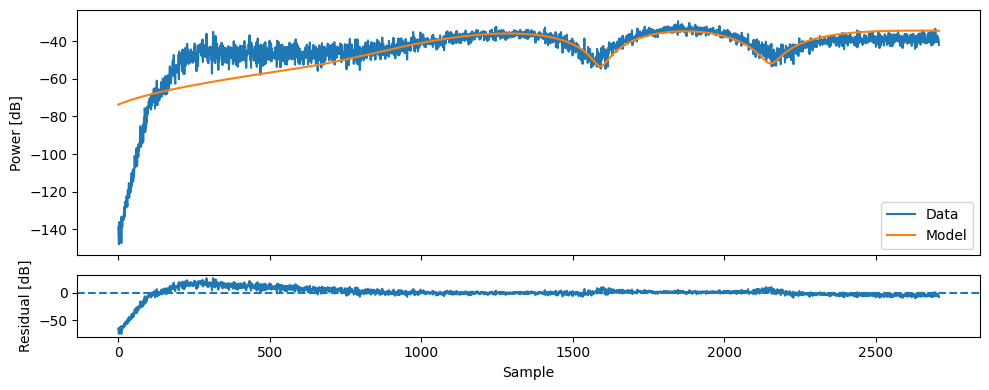

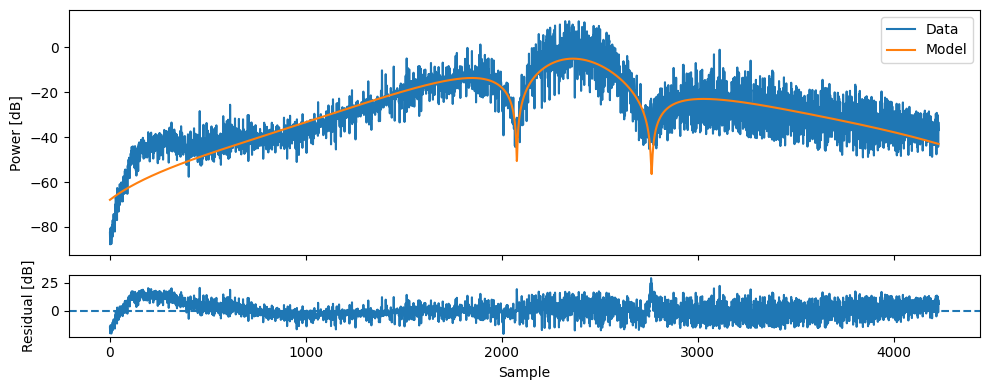

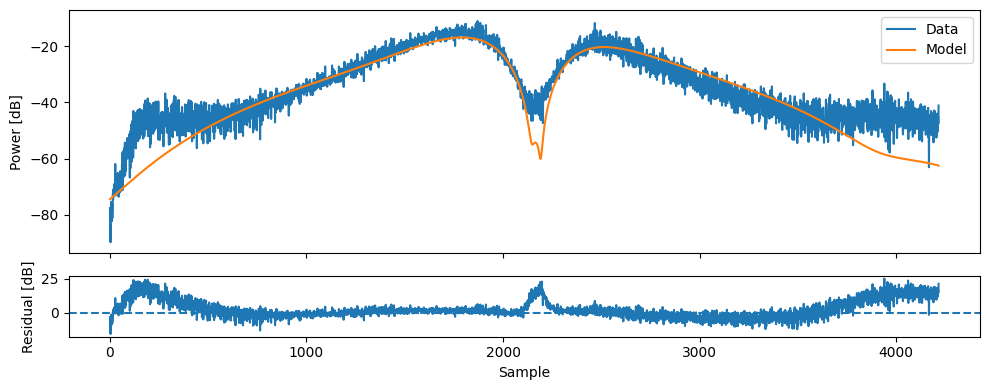

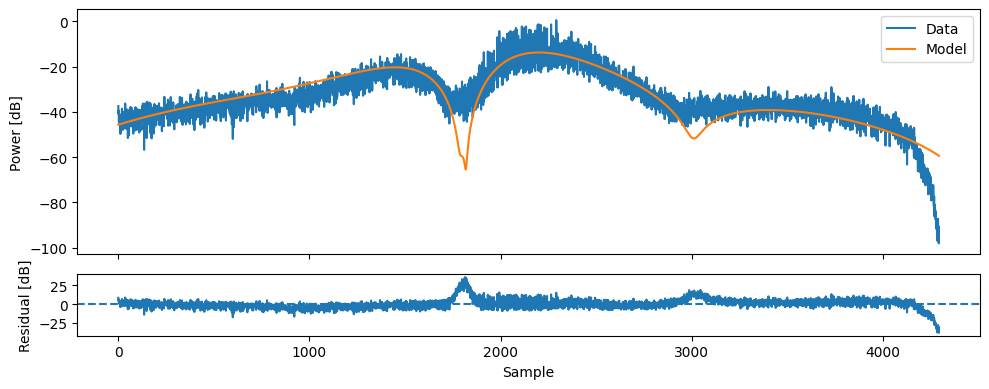

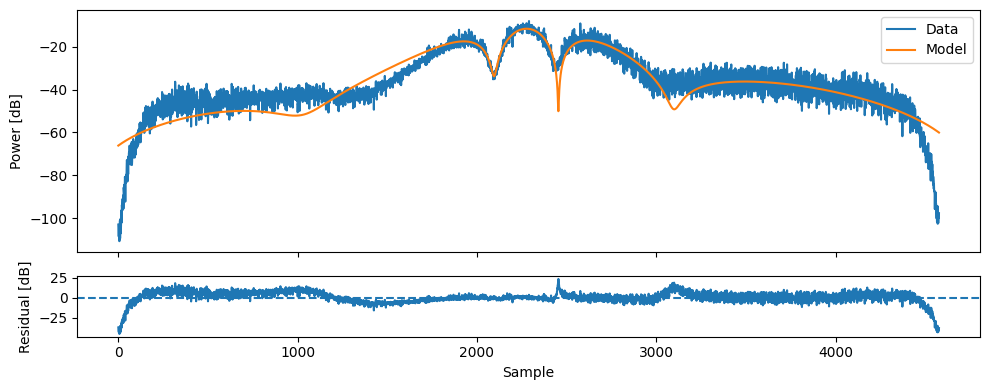

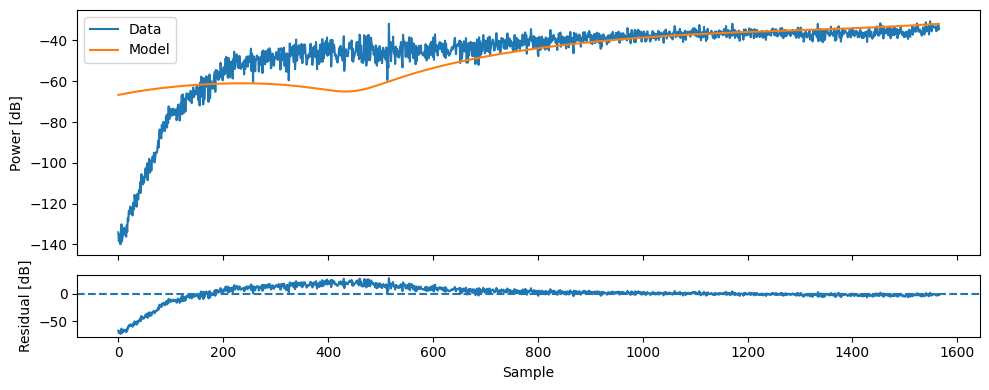

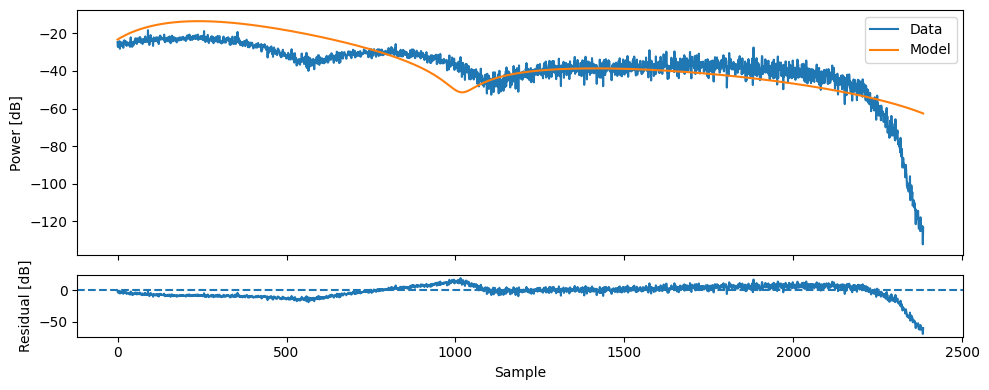

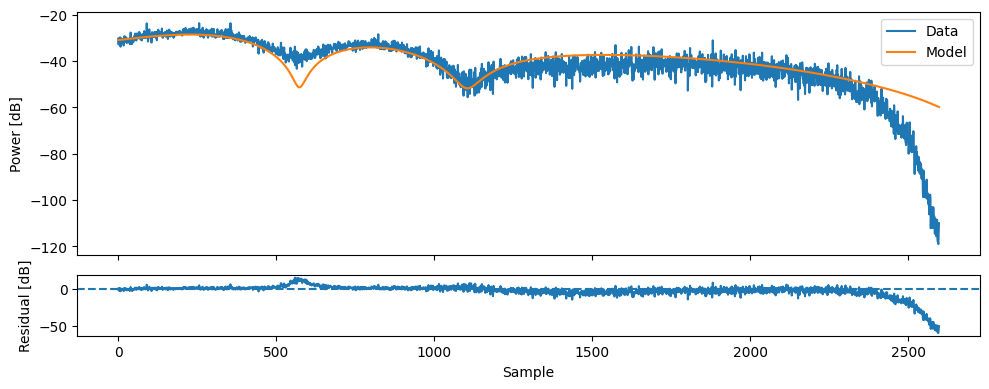

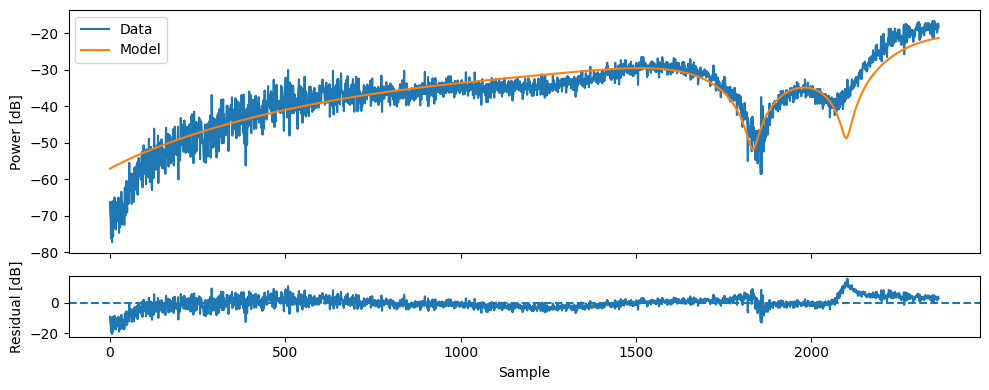

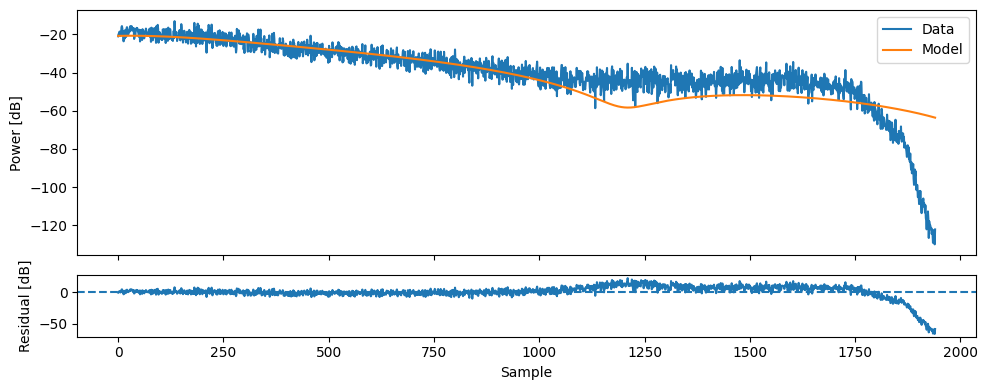

In [42]:
# pf_mc = PassFile("../passes/monotonic_concave_5hz/new/S06XX_rf0XX_passes.h5")
pf_mc = PassFile("../passes/monotonic_concave_5hz_pval/S06XX_rf0XX_passes.h5")
passes_mc = pf_mc.read_passes(pointing=0)

npix = hp.nside2npix(32)
beam = mwa_hyperbeam.FEEBeam(os.environ["MWA_BEAM_FILE"])

for pidx, pass_record in enumerate(passes_mc[:10]):
    alt_deg = np.asarray(pass_record.alt_deg, dtype=float)
    az_deg = np.asarray(pass_record.az_deg, dtype=float)
    power_db = np.asarray(pass_record.power_db, dtype=float)
    calibration_db = np.asarray(pass_record.cal_db, dtype=float)

    mwa_model_db = np.asarray(
        pass_hyperbeam_model(pass_record, beam),
        dtype=float,
    )
    residual_db = power_db - mwa_model_db

    metrics = evaluate_pass_fit(
        data_db=power_db,
        model_db=mwa_model_db,
        fit_min_db=-50.0,
        fit_max_db=0.0,
    )

    # try:
    #     corr.append(metrics["correlation"])
    # except:
    #     pass
    if metrics:
        sample = np.arange(power_db.size)
        mask = metrics["mask"]

        fig, ax = plt.subplots(2, 1, figsize=(10, 4), gridspec_kw={"height_ratios": [4, 1]}, sharex=True)
        
        ax[0].plot(sample, power_db, label="Data")
        ax[0].plot(sample, mwa_model_db, label="Model")
        # ax[0].plot(
        #     sample,
        #     metrics["offset_model_db"],
        #     label="Offset-fitted model",
        # )
        
        # ax[0].scatter(
        #     sample[mask],
        #     power_db[mask],
        #     s=3,
        #     alpha=0.2,
        #     label="Fit region",
        # )
        
        ax[0].set_ylabel("Power [dB]")
        ax[0].legend()
        
        
        ax[1].plot(
            sample,
            metrics["residual_db"],
        )
        
        ax[1].axhline(0, ls="--")
        ax[1].set_xlabel("Sample")
        ax[1].set_ylabel("Residual [dB]")
    
        # ax[0].set_title(f"Pass {pidx}: offset: {metrics["offset_db"]:.2f} dB, res MAD: {metrics["residual_rms_db"]:.2f} dB, res RMS:  {metrics["residual_rms_db"]:.2f} dB, res dynamic range: {metrics["residual_dynamic_range_db"]:.2f} dB, corr: {metrics["correlation"]:.4f}, ")
        
        plt.tight_layout()
        plt.show()

            # # if metrics is not None:
            # #     print(f"Offset:        {metrics["offset_db"]:.2f} dB")
            # #     print(f"Residual MAD:  {metrics["residual_mad_db"]:.2f} dB")
            # #     print(f"Residual RMS:  {metrics["residual_rms_db"]:.2f} dB")
            # #     print(f"Correlation:   {metrics["correlation"]:.4f}")
            # #     print(f"Dynamic range: {metrics["model_dynamic_range_db"]:.1f} dB")
            # #     print(f"Samples:       {metrics["n_samples"]}")
        
            # sample = np.arange(power_db.size)
            # mask = metrics["mask"]
            # fig, ax = plt.subplots(2, 1, figsize=(10, 4), gridspec_kw={"height_ratios": [4, 1]}, sharex=True)
            
            # ax[0].plot(sample, power_db, label="Measured")
            # ax[0].plot(sample, mwa_model_db, label="Original model")
            # ax[0].plot(
            #     sample,
            #     metrics["offset_model_db"],
            #     label="Offset-fitted model",
            # )
            
            # ax[0].scatter(
            #     sample[mask],
            #     power_db[mask],
            #     s=3,
            #     alpha=0.2,
            #     label="Fit region",
            # )
            
            # ax[0].set_ylabel("Power [dB]")
            # # ax.set_ylim(-90, 5)
            # ax[0].legend()
            
            
            # ax[1].plot(
            #     sample[mask],
            #     metrics["residual_db"][mask],
            # )
            
            # ax[1].axhline(0, ls="--")
            # ax[1].set_xlabel("Sample")
            # ax[1].set_ylabel("Residual [dB]")
        
            # ax[0].set_title(f"Pass {pidx}: offset: {metrics["offset_db"]:.2f} dB, res MAD: {metrics["residual_rms_db"]:.2f} dB, res RMS:  {metrics["residual_rms_db"]:.2f} dB, res dynamic range: {metrics["residual_dynamic_range_db"]:.2f} dB, corr: {metrics["correlation"]:.4f}, ")
            
            # plt.tight_layout()
            # plt.show()

In [29]:
pf_mc_orig = PassFile("../passes/rf0/S06XX_rf0XX_passes.h5")
pf_mc_pval = PassFile("../passes/monotonic_concave_5hz_pval/S06XX_rf0XX_passes.h5")

passes_mc_orig = pf_mc_orig.read_passes(pointing=0)
passes_mc_pval = pf_mc_pval.read_passes(pointing=0)

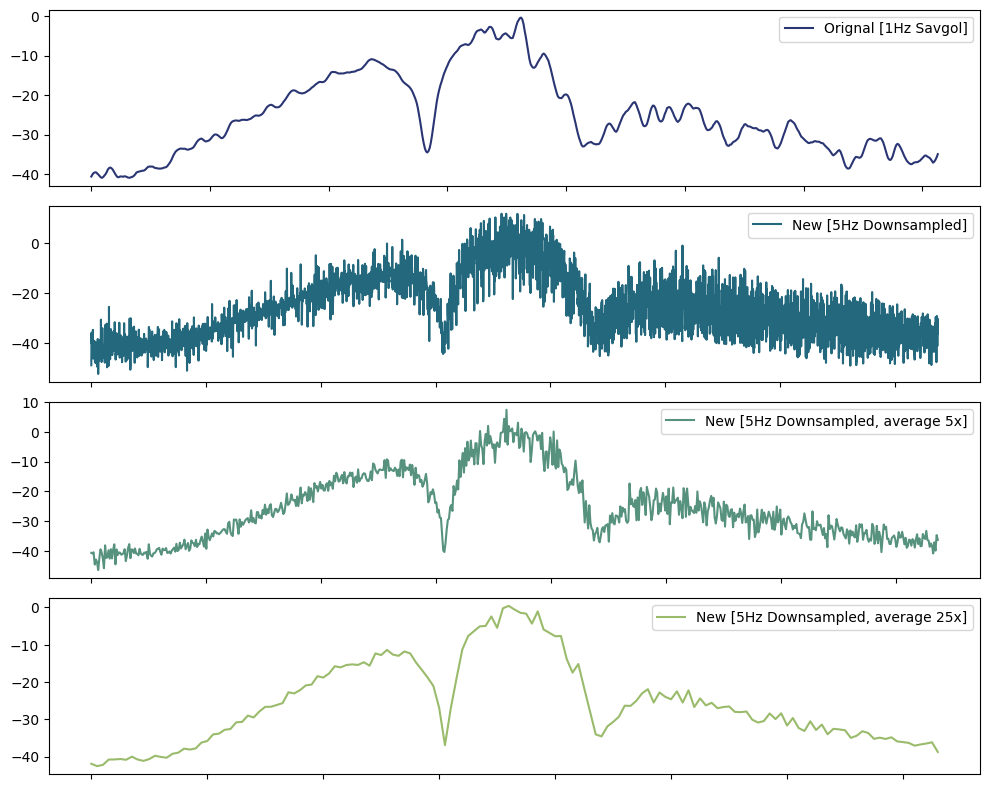

In [30]:
fig, ax = plt.subplots(4, 1, figsize=(10, 8))

po_1hz = passes_mc_orig[1]
pp_5hz = passes_mc_pval[1]

ax[0].plot(po_1hz.power_db[np.where(po_1hz.alt_deg>=7)[0]], label="Orignal [1Hz Savgol]", color=cmr.pride([0.1]))
ax[1].plot(pp_5hz.power_db[np.where(pp_5hz.alt_deg>=7)[0]], label="New [5Hz Downsampled]", color=cmr.pride([0.2]))
ax[2].plot(pp_5hz.power_db[np.where(pp_5hz.alt_deg>=7)[0]][:3685].reshape(-1, 5).mean(axis=1), label="New [5Hz Downsampled, average 5x]", color=cmr.pride([0.3]))
ax[3].plot(pp_5hz.power_db[np.where(pp_5hz.alt_deg>=7)[0]][:3675].reshape(-1, 25).mean(axis=1), label="New [5Hz Downsampled, average 25x]", color=cmr.pride([0.4]))

for a in ax:
    a.set(xticklabels=[])
    a.legend(loc="upper right")
    
plt.tight_layout()
plt.show()